# The climb into Taiwan's forced short-covering deadline (融券強制回補)

**The rule.** TWSE margin-trading rules (證券商辦理有價證券買賣融資融券業務操作辦法, Art. 76, current version amended
2026-01-09): before every shareholder meeting, ex-dividend/ex-rights date or cash capital raise, the issuer closes its
share register. *"自停止過戶前六個營業日起，停止融券賣出四日；已融券者，應於停止過戶第六個營業日（含）前，還券了結"* — new
margin shorts are banned for four days starting six business days before the book closure, and every existing margin
short must be bought back **by that same day**. Call it **D**. The date is public weeks ahead; the buying is forced.

**The question — the same one the gotobi pitch asked of 09:55.** Does the stock price climb as D approaches, and is
that climb bigger than what the same stock does over any ordinary 15-day stretch? If forced buying moves price, the
climb should (i) exist, (ii) be concentrated in stocks with a lot of short interest relative to volume, (iii) be
absent in stocks with no shorts to cover, and (iv) be specific to these dates.

**Design choices**
* **Climb(x)** = dividend-adjusted return from the close of D−x to the close of D, for x = 1…15.
* **Short pressure** is measured on D−17 (days-to-cover = short balance / 20-day average volume). TWSE publishes the
  balance that evening, so it is known before the longest climb window (entry at the close of D−16 or later) starts.
* **Null.** For each event, draw a random 15-day window from **the same stock**, away from any of its own ban windows,
  and compute the same climb. Averaging across events and repeating 2,000 times gives the distribution of the mean
  climb if the deadline did nothing. A second null draws only from the same calendar month in other years, to rule out
  seasonality (AGM season is May–June, ex-dividend season July–August).
* Returns are shown **raw** (what the price did) and **relative to the equal-weighted TWSE universe** (what the price
  did beyond the market that day).

## 1. Data
**What this does.** Loads the TWSE daily panel (prices, ex-dividend reference prices, margin/short balances, TAIEX)
and the FinMind short-sale-ban calendar, builds dividend-adjusted daily returns, and lays everything out as
*days × stocks* matrices.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.formula.api as smf

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
DATA = Path("data")
X_MAX = 15            # longest climb window (trading days before D)
SIG_LAG = X_MAX + 2   # short pressure measured at D-17: published that evening, tradable from the close of D-16
POST = 10             # days after D shown on the path plots
IS_END = pd.Timestamp("2023-12-31")
N_BOOT = 2000
COST_STOCK_BPS, COST_FUT_BPS, MIN_VAL20 = 55, 20, 2e7
rng = np.random.default_rng(7)

is_stock = lambda s: s.str.fullmatch(r"[1-9]\d{3}")
px = pd.read_csv(DATA / "prices.csv", dtype={"stock_id": str}, parse_dates=["date"])
px = px[is_stock(px.stock_id)].drop_duplicates(["date", "stock_id"]).sort_values(["stock_id", "date"])
exd = pd.read_csv(DATA / "exdiv.csv", dtype={"stock_id": str}, parse_dates=["date"])
exd = exd.dropna(subset=["close_before", "ref_price"]).drop_duplicates(["date", "stock_id"])
exd["adj"] = exd.ref_price / exd.close_before
px = px.merge(exd[["date", "stock_id", "adj"]], on=["date", "stock_id"], how="left")
px["adj"] = px["adj"].fillna(1.0)
px["close_ff"] = px.groupby("stock_id")["close"].ffill()
px["ret"] = px.close / (px.groupby("stock_id")["close_ff"].shift() * px.adj) - 1
px.loc[px.ret.abs() > 0.105, "ret"] = np.nan      # 10% daily limit: bigger = split / capital reduction / relisting

idx = pd.read_csv(DATA / "index.csv", parse_dates=["date"]).drop_duplicates("date").sort_values("date").set_index("date")
cal = idx.index
mkt_tx = idx.taiex_tr.pct_change(fill_method=None)
mg = pd.read_csv(DATA / "margin.csv", dtype={"stock_id": str}, parse_dates=["date"])
mg = mg[is_stock(mg.stock_id)].drop_duplicates(["date", "stock_id"])
stocks = pd.Index(sorted(set(px.stock_id) & set(mg.stock_id)))
wide = lambda df, c: df.pivot(index="date", columns="stock_id", values=c).reindex(index=cal, columns=stocks)

R = wide(px, "ret")
mkt_ew = R.mean(axis=1)
SB, COVB = wide(mg, "short_bal"), wide(mg, "short_buy")
ADV = (wide(px, "volume") / 1000).rolling(20, min_periods=10).mean()
VAL20 = wide(px, "value").rolling(20, min_periods=10).mean()
col = {s: i for i, s in enumerate(stocks)}
T, N = R.shape

def cumsum0(M):   # C[t+1] - C[a] = sum of M[a..t]
    return np.vstack([np.zeros((1, M.shape[1])), np.nancumsum(M, axis=0)])
LR = np.log1p(R.values)
C_RAW = cumsum0(LR)
C_EW = cumsum0(LR - np.log1p(mkt_ew.values)[:, None])
C_TX = cumsum0(LR - np.log1p(mkt_tx.values)[:, None])
TRADED = ~np.isnan(R.values)
print(f"{T} trading days {cal[0].date()} -> {cal[-1].date()}, {N} stocks")

2122 trading days 2018-01-02 -> 2026-09-23, 1111 stocks


**What this does.** Builds the event calendar. D is the first day of each short-sale ban (= the last covering day under
Art. 76). Keeps one event per stock per 10 trading days, measures short pressure on D−17, and forms days-to-cover
quintiles **within each year** (so a breakpoint never uses later years). Events whose stock had **no** margin shorts on
D−17 are kept as a separate control group: the calendar hits them too, but there is nothing to cover.

In [2]:
REASON = [("股東常會", "AGM"), ("股東臨時會", "EGM"), ("除權息", "ex-rights+div"), ("除息", "ex-div"), ("除權", "ex-rights"),
          ("現金增資", "cash raise")]
def reason_en(s):
    for k, v in REASON:
        if k in s:
            return v
    return "other"

ev = pd.read_csv(DATA / "suspension.csv", dtype={"stock_id": str}, parse_dates=["date", "end_date"]).drop_duplicates()
ev = ev[ev.stock_id.isin(stocks)].copy()
ev["why"] = ev.reason.map(reason_en)
ev["D"] = cal.searchsorted(ev.date.values)
ev = ev[(ev.D >= SIG_LAG + 1) & (ev.D < T - 1)]
ev["j"] = ev.stock_id.map(col)
ev = ev.sort_values(["stock_id", "D"])
ev = ev[ev.groupby("stock_id").D.diff().fillna(99) >= 10].reset_index(drop=True)
ev["Ddate"] = cal[ev.D.values]
ev["year"] = ev.Ddate.dt.year
ev["oos"] = ev.Ddate > IS_END

s_ = ev.D.values - SIG_LAG
J = ev.j.values
ev["sb_sig"] = SB.values[s_, J]
ev["dtc"] = SB.values[s_, J] / ADV.values[s_, J]
ev["size"] = VAL20.values[s_, J]
ev["sb_pre"] = SB.values[ev.D.values - 1, J]
ev = ev[np.isfinite(ev.sb_sig) & np.isfinite(ev["size"])].reset_index(drop=True)
quint = lambda s: np.ceil(s.rank(method="first", pct=True) * 5)
ev["grp"] = "no shorts"
has = (ev.sb_sig > 0) & np.isfinite(ev.dtc)
ev.loc[has, "grp"] = "Q" + ev[has].groupby("year").dtc.transform(quint).astype(int).astype(str)
GROUPS = ["no shorts", "Q1", "Q2", "Q3", "Q4", "Q5"]
D, J = ev.D.values, ev.j.values
print(f"{len(ev):,} events on {ev.Ddate.nunique()} deadline dates, {ev.stock_id.nunique()} stocks")
print(ev.groupby("grp").agg(n=("dtc", "size"), dtc_median=("dtc", "median"), size_median_NTm=("size", lambda s: s.median() / 1e6)).round(3).to_string())
print(ev.why.value_counts().to_string())

16,094 events on 1350 deadline dates, 1098 stocks
              n  dtc_median  size_median_NTm
grp                                         
Q1         2280       0.004           43.063
Q2         2284       0.016           52.105
Q3         2285       0.040           73.176
Q4         2284       0.086          114.959
Q5         2287       0.254           74.719
no shorts  4674       0.000            3.513
why
AGM              8419
ex-div           6323
ex-rights+div     554
cash raise        383
other             275
ex-rights         140


## 2. The mechanism: when does the forced buying happen?
**What this does.** Average short balance (relative to its level on D−17) and daily buy-to-cover volume (as a multiple
of normal daily volume) from D−15 to D+10, by short-pressure group. The climb, if there is one, should line up with
the buying.

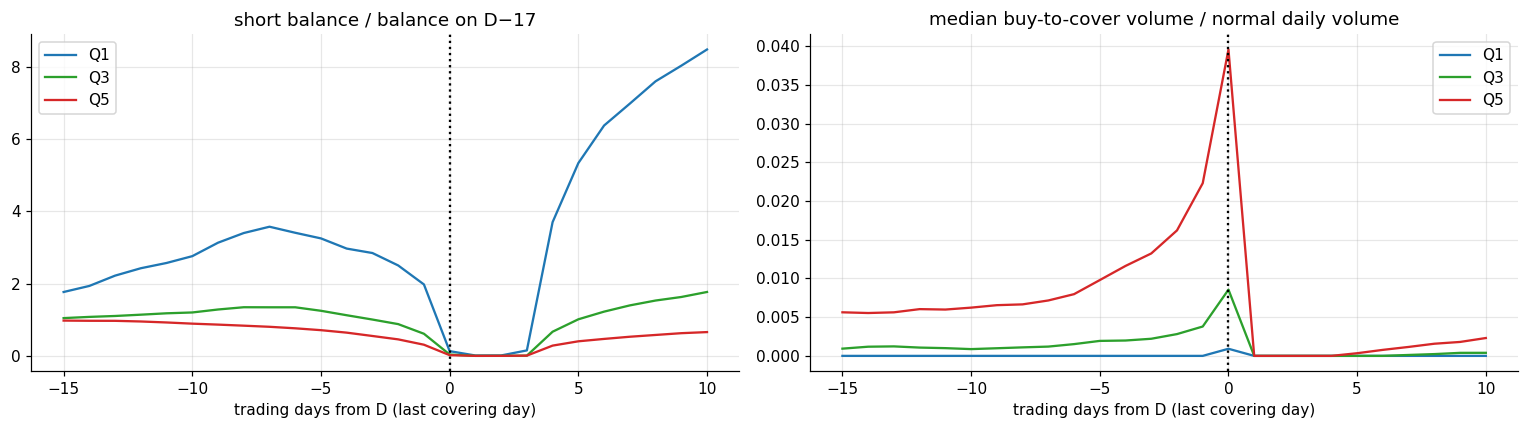

Q5 short balance left on D-15: 98%
Q5 short balance left on D-10: 89%
Q5 short balance left on D-5: 71%
Q5 short balance left on D-3: 55%
Q5 short balance left on D-1: 31%
Q5 short balance left on D+0: 2%


In [3]:
offs = np.arange(-X_MAX, POST + 1)
def ev_mat(M, D_, J_):
    ii = D_[:, None] + offs[None, :]
    ok = (ii >= 0) & (ii < T)
    out = np.full(ii.shape, np.nan)
    out[ok] = M[ii[ok], np.broadcast_to(J_[:, None], ii.shape)[ok]]
    return out

base = ev.sb_sig.where(ev.sb_sig > 0).values[:, None]
SBn = ev_mat(SB.values, D, J) / base
CFn = ev_mat(COVB.values, D, J) / ADV.values[D - SIG_LAG, J][:, None]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for g_, c in [("Q1", "C0"), ("Q3", "C2"), ("Q5", "C3")]:
    m = (ev.grp == g_).values
    ax[0].plot(offs, np.nanmean(SBn[m], 0), color=c, label=g_)
    ax[1].plot(offs, np.nanmedian(CFn[m], 0), color=c, label=g_)
ax[0].set_title("short balance / balance on D−17"); ax[1].set_title("median buy-to-cover volume / normal daily volume")
for a in ax: a.axvline(0, color="k", ls=":"); a.legend(); a.set_xlabel("trading days from D (last covering day)")
plt.tight_layout(); plt.show()

q5 = (ev.grp == "Q5").values
left = np.nanmean(SBn[q5], 0)
for d_ in [-15, -10, -5, -3, -1, 0]:
    print(f"Q5 short balance left on D{d_:+d}: {left[offs == d_][0]:.0%}")

## 3. The climb
**What this does.** Mean climb(x) for x = 1…15 by group, raw and relative to the equal-weighted market, plus the
average price path from D−15 to D+10 with 95% confidence bands (standard errors clustered by deadline date, because
dozens of stocks share each AGM date).

x                      1     3     5      10     15
kind      group                                    
raw       Q1          4.4  25.2  38.4   99.4  128.4
          Q2          8.9  43.5  48.1  114.9  141.5
          Q3          3.4  33.7  55.2  103.2  107.3
          Q4          9.3  48.6  65.0  124.9  146.6
          Q5         23.9  71.5  96.8  121.9   87.2
          no shorts  10.8  38.9  39.1   72.2   79.5
vs market Q1         -0.4  -7.8  12.5   54.2   71.1
          Q2          3.7  10.8  11.2   48.5   67.7
          Q3          0.4  -2.5  13.9   35.8   24.0
          Q4         -0.3   8.5  17.3   50.2   69.4
          Q5         13.6  32.4  49.7   59.3   41.1
          no shorts   3.8   4.9  -0.8    6.7    5.6

t-stats (clustered by deadline date)
x                      1     3     5     10    15
kind      group                                  
raw       Q1         0.61  2.31  1.84  3.33  3.26
          Q2         0.99  3.32  2.29  3.46  3.46
          Q3         0.36  2.31  2

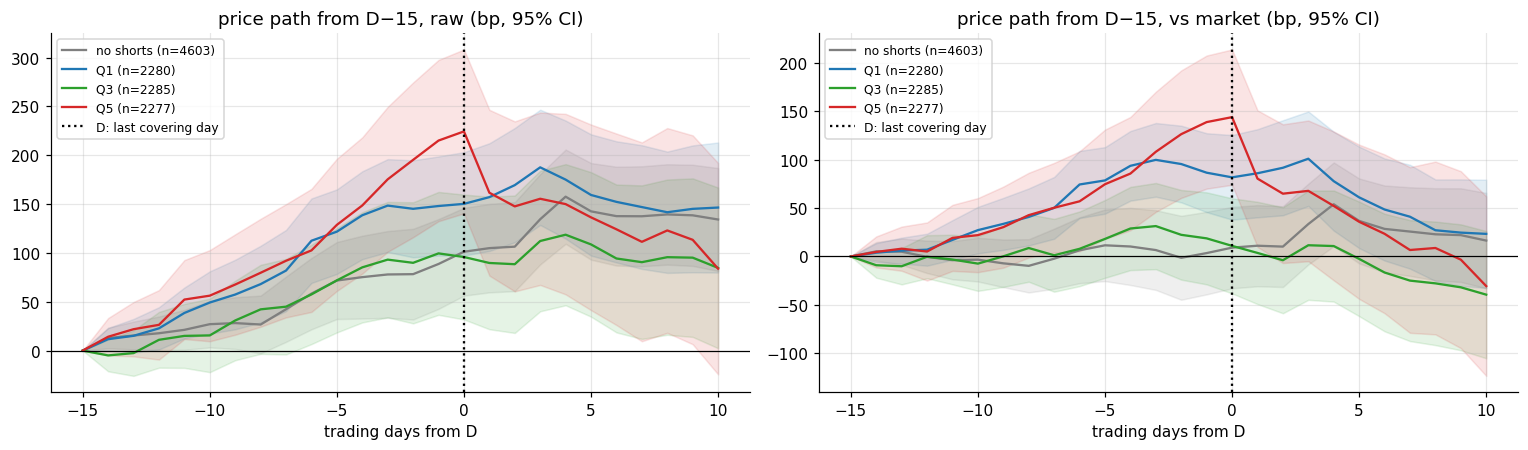

In [4]:
XS = np.arange(1, X_MAX + 1)
def climb(D_, J_, C):
    # (n, 15): log return from the close of D-x to the close of D, x = 1..15
    return C[D_ + 1, J_][:, None] - C[(D_ + 1)[:, None] - XS[None, :], J_[:, None]]

ok_ev = TRADED[D, J] & TRADED[D - X_MAX, J]
CL = {"raw": climb(D, J, C_RAW), "vs market": climb(D, J, C_EW)}
for k in CL: CL[k][~ok_ev] = np.nan

def clustered_mean(x, dates):
    d = pd.DataFrame({"x": x, "d": dates}).dropna()
    g = d.groupby("d").x.agg(["sum", "count"])
    m = g["sum"].sum() / g["count"].sum()
    resid = (g["sum"] - m * g["count"]).values
    se = np.sqrt((resid ** 2).sum()) / g["count"].sum()
    return m, se

rows = []
for kind, M in CL.items():
    for g_ in GROUPS:
        m = (ev.grp == g_).values
        for x in [1, 3, 5, 10, 15]:
            mu, se = clustered_mean(M[m, x - 1], ev.Ddate.values[m])
            rows.append(dict(kind=kind, group=g_, x=x, mean_bp=mu * 1e4, t=mu / se))
tab = pd.DataFrame(rows)
print(tab.pivot_table(index=["kind", "group"], columns="x", values="mean_bp").round(1).to_string())
print("\nt-stats (clustered by deadline date)")
print(tab.pivot_table(index=["kind", "group"], columns="x", values="t").round(2).to_string())

path = {k: ev_mat(np.nan_to_num(LR - (0 if k == "raw" else np.log1p(mkt_ew.values)[:, None])), D, J) for k in CL}
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for a, k in zip(ax, path):
    P = np.cumsum(path[k], 1); P = (P - P[:, [0]]) * 1e4      # 0 at the close of D-15
    for g_, c in [("no shorts", "C7"), ("Q1", "C0"), ("Q3", "C2"), ("Q5", "C3")]:
        m = (ev.grp == g_).values & ok_ev
        df = pd.DataFrame(P[m], columns=offs).assign(d=ev.Ddate.values[m]).groupby("d").mean()
        mu, se = df.mean(), df.std() / np.sqrt(len(df))
        a.plot(offs, mu, color=c, label=f"{g_} (n={m.sum()})"); a.fill_between(offs, mu - 1.96 * se, mu + 1.96 * se, color=c, alpha=.12)
    a.axvline(0, color="k", ls=":", label="D: last covering day"); a.axhline(0, color="k", lw=.8)
    a.set_title(f"price path from D−15, {k} (bp, 95% CI)"); a.set_xlabel("trading days from D"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation.**
- **Mechanism.** In the top days-to-cover quintile, 89% of the short balance is still open on D−10 and 71% on D−5.
  Then it collapses: 55% on D−3, 31% on D−1, 2% on D. About **70% of the forced buying lands in the last five
  trading days**. The flow is not huge: the median Q5 stock has ~0.25 days of volume to cover in total. So we
  should expect a modest average effect, concentrated in the names where the short book is large.
- **Raw prices rise into D for every group**, including stocks with no shorts at all. The market itself tends to rise
  over these weeks (Taiwan's AGM and ex-dividend seasons), so the raw climb cannot be read as covering pressure.
- **Relative to the market, only the heavily shorted stocks climb in the last days:** Q5 is +14bp over the final day,
  +32bp over three, **+50bp over five (t = 3.7)**, peaking near +60bp at x ≈ 6–9. Q1–Q4 are flat for x ≤ 3; the
  no-shorts control is ≈ 0 at every horizon.
- Further back (x = 10–15), *every* shortable group gains 25–70bp versus the market, Q1 as much as Q5. That longer
  drift belongs to the calendar (dividend-capture buying ahead of the ex-date, AGM season), not to short covering.

## 4. Is the climb bigger than an ordinary 15 days for the same stock? (bootstrap)
**What this does.** The core test. For every event, the null is a random 15-day window from **the same stock**, ending
on a day that is not within [D−15, D+25] of any of that stock's own deadlines (so no random window overlaps a real
climb or its aftermath). One draw = one random window per event; the statistic is the mean climb(x) across events in a
group. 2,000 draws give the null distribution for every x. p-values are one-sided (real ≥ null), since the thesis
predicts a rise.

The **same-season** version only draws windows ending in the same calendar month as the real deadline, in a different
year — so AGM-season or dividend-season drift cannot explain the result.

In [5]:
# valid random-window end days per stock: traded, room for a 15-day window, not near any of the stock's own deadlines
VALID = TRADED.copy()
VALID[: X_MAX + 1] = False
for d_, j_ in zip(D, J):
    VALID[max(d_ - X_MAX, 0): min(d_ + 26, T), j_] = False
VALID &= np.roll(TRADED, X_MAX, axis=0)      # the window's start day traded too

def make_pools(key_fn):
    # key_fn(e_idx, j) -> pool key; returns concat array of end days + per-event (start, size)
    keys = {}
    ee, jj = np.nonzero(VALID)
    for e_, j_ in zip(ee, jj):
        keys.setdefault(key_fn(e_, j_), []).append(e_)
    return keys

month = cal.month.values; yr = cal.year.values
pools_stock = make_pools(lambda e_, j_: j_)
pools_season = make_pools(lambda e_, j_: (j_, month[e_], yr[e_]))

def event_pool(pools, keys_per_event):
    flat, start, size = [], np.zeros(len(ev), int), np.zeros(len(ev), int)
    cache, offset = {}, 0
    for i, ks in enumerate(keys_per_event):
        kk = tuple(ks)
        if kk not in cache:
            arr = np.concatenate([np.asarray(pools[k]) for k in ks if k in pools] or [np.array([], int)])
            cache[kk] = (offset, len(arr)); flat.append(arr); offset += len(arr)
        start[i], size[i] = cache[kk]
    return np.concatenate(flat).astype(np.int32), start, size

P_STOCK = event_pool(pools_stock, [[j_] for j_ in J])
P_SEASON = event_pool(pools_season, [[(j_, m_, y_) for y_ in range(cal[0].year, cal[-1].year + 1) if y_ != yv]
                                     for j_, m_, yv in zip(J, month[D], yr[D])])
print(f"median random windows available per event: same stock {np.median(P_STOCK[2]):.0f}, same stock & month {np.median(P_SEASON[2]):.0f}")

def bootstrap(pool, C, CLk, n_boot=N_BOOT, chunk=40):
    flat, start, size = pool
    ok = size > 0
    gmask = {g_: ((ev.grp == g_).values & ok_ev & ok) for g_ in GROUPS}
    gmask["Q5-Q1"] = None
    out = {g_: np.empty((n_boot, X_MAX)) for g_ in gmask}
    Jc = J.copy()
    for b0 in range(0, n_boot, chunk):
        nb = min(chunk, n_boot - b0)
        u = rng.random((nb, len(ev)))
        E = flat[np.minimum(start + (u * size).astype(int), len(flat) - 1)]            # (nb, n) random end days
        cl = C[E + 1, Jc][..., None] - C[(E + 1)[..., None] - XS, Jc[None, :, None]]  # (nb, n, 15)
        cl[:, ~ok] = np.nan
        for g_, m in gmask.items():
            if m is not None:
                out[g_][b0:b0 + nb] = np.nanmean(cl[:, m], axis=1)
        out["Q5-Q1"][b0:b0 + nb] = out["Q5"][b0:b0 + nb] - out["Q1"][b0:b0 + nb]
    real = {g_: np.nanmean(CLk[m], 0) for g_, m in gmask.items() if m is not None}
    real["Q5-Q1"] = real["Q5"] - real["Q1"]
    return real, out

res = {}
for kind, CM in [("raw", C_RAW), ("vs market", C_EW)]:
    for pname, pool in [("same stock", P_STOCK), ("same stock, same month", P_SEASON)]:
        res[(kind, pname)] = bootstrap(pool, CM, CL[kind])

def summary(real, null, g_):
    r, n = real[g_] * 1e4, null[g_] * 1e4
    return pd.DataFrame({"real_bp": r, "null_mean_bp": n.mean(0), "null_97.5%": np.percentile(n, 97.5, axis=0),
                         "excess_bp": r - n.mean(0), "z": (r - n.mean(0)) / n.std(0),
                         "p_one_sided": ((n >= r).sum(0) + 1) / (len(n) + 1)}, index=pd.Index(XS, name="x"))

for g_ in ["Q5", "Q1", "no shorts", "Q5-Q1"]:
    print(f"\n==== {g_}: climb(x) vs same-stock random 15-day windows, relative to market")
    print(summary(*res[("vs market", "same stock")], g_).round(3).to_string())

median random windows available per event: same stock 1368, same stock & month 22



==== Q5: climb(x) vs same-stock random 15-day windows, relative to market
    real_bp  null_mean_bp  null_97.5%  excess_bp      z  p_one_sided
x                                                                   
1    13.603        -0.767       8.333     14.370  2.958        0.000
2    19.167        -1.745      11.749     20.912  3.013        0.001
3    32.405        -2.523      14.326     34.928  4.051        0.000
4    38.448        -3.346      16.960     41.793  4.174        0.000
5    49.654        -4.298      18.621     53.952  4.780        0.000
6    61.075        -5.018      19.446     66.093  5.368        0.000
7    60.797        -5.660      20.796     66.457  4.937        0.000
8    61.988        -6.478      21.801     68.466  4.788        0.000
9    63.804        -7.279      22.865     71.083  4.779        0.000
10   59.278        -8.108      22.968     67.386  4.264        0.000
11   52.727        -9.181      23.504     61.908  3.722        0.000
12   47.448       -10.185   

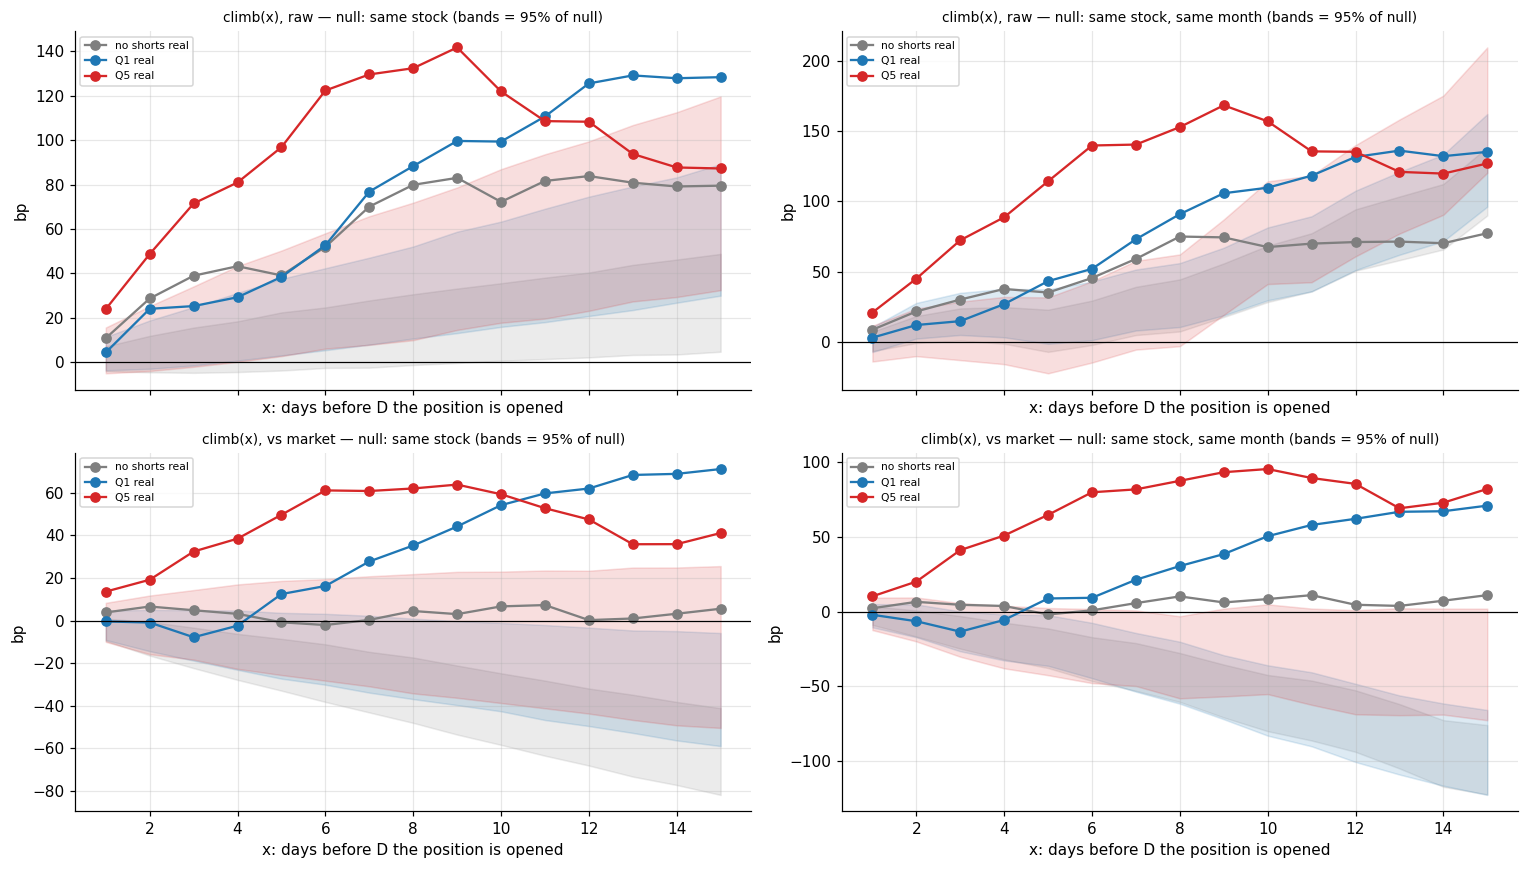

                                            x=3 excess  x=5 excess  x=10 excess  x=15 excess  x=3 p  x=5 p  x=10 p  x=15 p
returns   null                   group                                                                                    
raw       same stock             no shorts      33.592      29.835       53.487       52.521  0.000  0.000   0.000   0.000
                                 Q1             13.439      18.582       60.045       69.915  0.023  0.018   0.000   0.000
                                 Q2             29.667      25.438       70.030       75.077  0.000  0.010   0.000   0.000
                                 Q3             17.806      28.785       51.831       33.390  0.020  0.004   0.001   0.040
                                 Q4             30.822      35.319       66.761       61.451  0.000  0.000   0.000   0.001
                                 Q5             55.732      70.609       69.607       11.304  0.000  0.000   0.000   0.303
                

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax_row, kind in zip(axes, ["raw", "vs market"]):
    for a, pname in zip(ax_row, ["same stock", "same stock, same month"]):
        real, null = res[(kind, pname)]
        for g_, c in [("no shorts", "C7"), ("Q1", "C0"), ("Q5", "C3")]:
            n = null[g_] * 1e4
            a.plot(XS, real[g_] * 1e4, "o-", color=c, label=f"{g_} real")
            a.fill_between(XS, np.percentile(n, 2.5, 0), np.percentile(n, 97.5, 0), color=c, alpha=.15)
        a.axhline(0, color="k", lw=.8); a.set_title(f"climb(x), {kind} — null: {pname} (bands = 95% of null)", fontsize=9)
        a.set_xlabel("x: days before D the position is opened"); a.set_ylabel("bp"); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

rows = []
for (kind, pname), (real, null) in res.items():
    for g_ in GROUPS + ["Q5-Q1"]:
        s = summary(real, null, g_)
        best = s.z.idxmax()
        rows.append(dict(returns=kind, null=pname, group=g_, **{f"x={x} excess": s.loc[x, "excess_bp"] for x in [3, 5, 10, 15]},
                         **{f"x={x} p": s.loc[x, "p_one_sided"] for x in [3, 5, 10, 15]}))
print(pd.DataFrame(rows).set_index(["returns", "null", "group"]).round(3).to_string())

**Interpretation.**
- **The random-window null drifts down** (about −1 to −4bp a day versus the market, most in the smallest names).
  Log returns of volatile single stocks carry a volatility drag against an equal-weighted index, so *every* group,
  even no-shorts, looks "significant" against its own random windows at long horizons. On its own, "Q5 beats its
  null" is not evidence.
- **The clean test is Q5 − Q1 against the same null**, where the drag and the calendar cancel. The heavily shorted
  names beat the lightly shorted names by **+36bp over the last 3 days (p < 0.001)**, +35bp over 4 (p = 0.001),
  +30bp over 5 (p = 0.02) and +36bp over 6 (p = 0.008). The edge is gone by x ≈ 8 and turns negative for x ≥ 10,
  because Q1 catches up on the generic longer-horizon drift.
- The **same-season null** (only windows from the same calendar month in other years) makes it stronger, not
  weaker: the Q5 − Q1 excess is +54bp at x = 3 and +56bp at x = 5, both p < 0.001. This is not AGM- or dividend-season drift.
- The climb shows up over the last 3–6 days, the same days ~70% of the forced buying happens. The timing matches the mechanism.

### 4b. Bootstrap on the bucket's t-stat
**What this does.** The same question in t-stat form.
1. **Real statistic.** For every deadline date, average the climb(x) of the bucket's stocks on that date (one
   portfolio return per date), then take the t-stat of those portfolio returns across dates.
2. **Null.** Keep every date's bucket of stocks, but give the whole cohort one random x-day window (the same window
   for every stock on that date, so the stocks' co-movement is preserved). The window must end at least 16 trading
   days after the start of the sample, and no stock may be inside [D−15, D+25] of one of its own deadlines. Recompute
   the portfolio returns and the t-stat. Repeat 1,000 times.
3. Plot the 1,000 null t-stats and mark where the real t-stat falls.

Q5 − Q1 uses the same random window for both buckets on each date, so it is a within-date spread in the null too.

In [7]:
N_T_BOOT = 1000
coh, coh_idx = np.unique(ev.Ddate.values, return_inverse=True)
n_coh = len(coh)
D_coh = cal.searchsorted(coh)
grp = ev.grp.values

def coh_mean(vals, mask):
    # mean of vals over events in mask, per cohort (NaN where the cohort has none)
    w = mask & np.isfinite(vals)
    s_ = np.bincount(coh_idx[w], weights=vals[w], minlength=n_coh)
    c_ = np.bincount(coh_idx[w], minlength=n_coh)
    return np.where(c_ > 0, s_ / np.maximum(c_, 1), np.nan)

def tstat(r):
    r = r[np.isfinite(r)]
    return r.mean() / r.std(ddof=1) * np.sqrt(len(r)), r.mean(), len(r)

def bucket_ret(cl_vals, valid, g_):
    if g_ == "Q5-Q1":
        return coh_mean(cl_vals, valid & (grp == "Q5")) - coh_mean(cl_vals, valid & (grp == "Q1"))
    return coh_mean(cl_vals, valid & (grp == g_))

def random_ends():
    e = rng.integers(X_MAX + 1, T - 1, n_coh)
    bad = (e >= D_coh - X_MAX) & (e <= D_coh + 25)
    while bad.any():
        e[bad] = rng.integers(X_MAX + 1, T - 1, bad.sum())
        bad = (e >= D_coh - X_MAX) & (e <= D_coh + 25)
    return e

BUCKETS = ["Q5", "Q1", "no shorts", "Q5-Q1"]
XT = [3, 5, 10, 15]
tres = {}
for kind, CM in [("vs market", C_EW), ("raw", C_RAW)]:
    real = {}
    for x in XT:
        cl_real = CL[kind][:, x - 1]
        for g_ in BUCKETS:
            real[(g_, x)] = tstat(bucket_ret(cl_real, ok_ev, g_))
    null = {k: np.empty(N_T_BOOT) for k in real}
    for b in range(N_T_BOOT):
        E = random_ends()[coh_idx]                       # one random window end per cohort, shared by its stocks
        valid = VALID[E, J]
        for x in XT:
            cl_b = C_EW[E + 1, J] - C_EW[E + 1 - x, J] if kind == "vs market" else C_RAW[E + 1, J] - C_RAW[E + 1 - x, J]
            for g_ in BUCKETS:
                null[(g_, x)][b] = tstat(bucket_ret(cl_b, valid, g_))[0]
    tres[kind] = (real, null)

for kind, (real, null) in tres.items():
    rows = []
    for (g_, x), (t_real, mu, n_) in real.items():
        nl = null[(g_, x)]
        rows.append(dict(bucket=g_, x=x, dates=n_, real_mean_bp=mu * 1e4, real_t=t_real, null_t_mean=nl.mean(),
                         null_t_2_5=np.percentile(nl, 2.5), null_t_97_5=np.percentile(nl, 97.5),
                         pct_rank=(nl < t_real).mean() * 100, p_one_sided=((nl >= t_real).sum() + 1) / (len(nl) + 1)))
    print(f"\n==== {kind}: real t-stat vs 1,000 random-window t-stats")
    print(pd.DataFrame(rows).set_index(["bucket", "x"]).round(3).to_string())


==== vs market: real t-stat vs 1,000 random-window t-stats
              dates  real_mean_bp  real_t  null_t_mean  null_t_2_5  null_t_97_5  pct_rank  p_one_sided
bucket    x                                                                                           
Q5        3     685        35.849   2.480       -0.182      -2.278        1.799      99.7        0.004
Q1        3     676       -18.084  -2.037       -0.708      -2.763        1.228      10.8        0.892
no shorts 3     906         2.524   0.303       -1.177      -3.259        0.730      92.5        0.076
Q5-Q1     3     427        60.567   2.927        0.314      -1.610        2.165      99.9        0.002
Q5        5     685        69.407   3.801       -0.240      -2.197        1.830     100.0        0.001
Q1        5     676         3.182   0.242       -0.854      -2.902        1.088      86.0        0.141
no shorts 5     906        -2.408  -0.218       -1.469      -3.505        0.628      89.1        0.110
Q5-Q1     5  

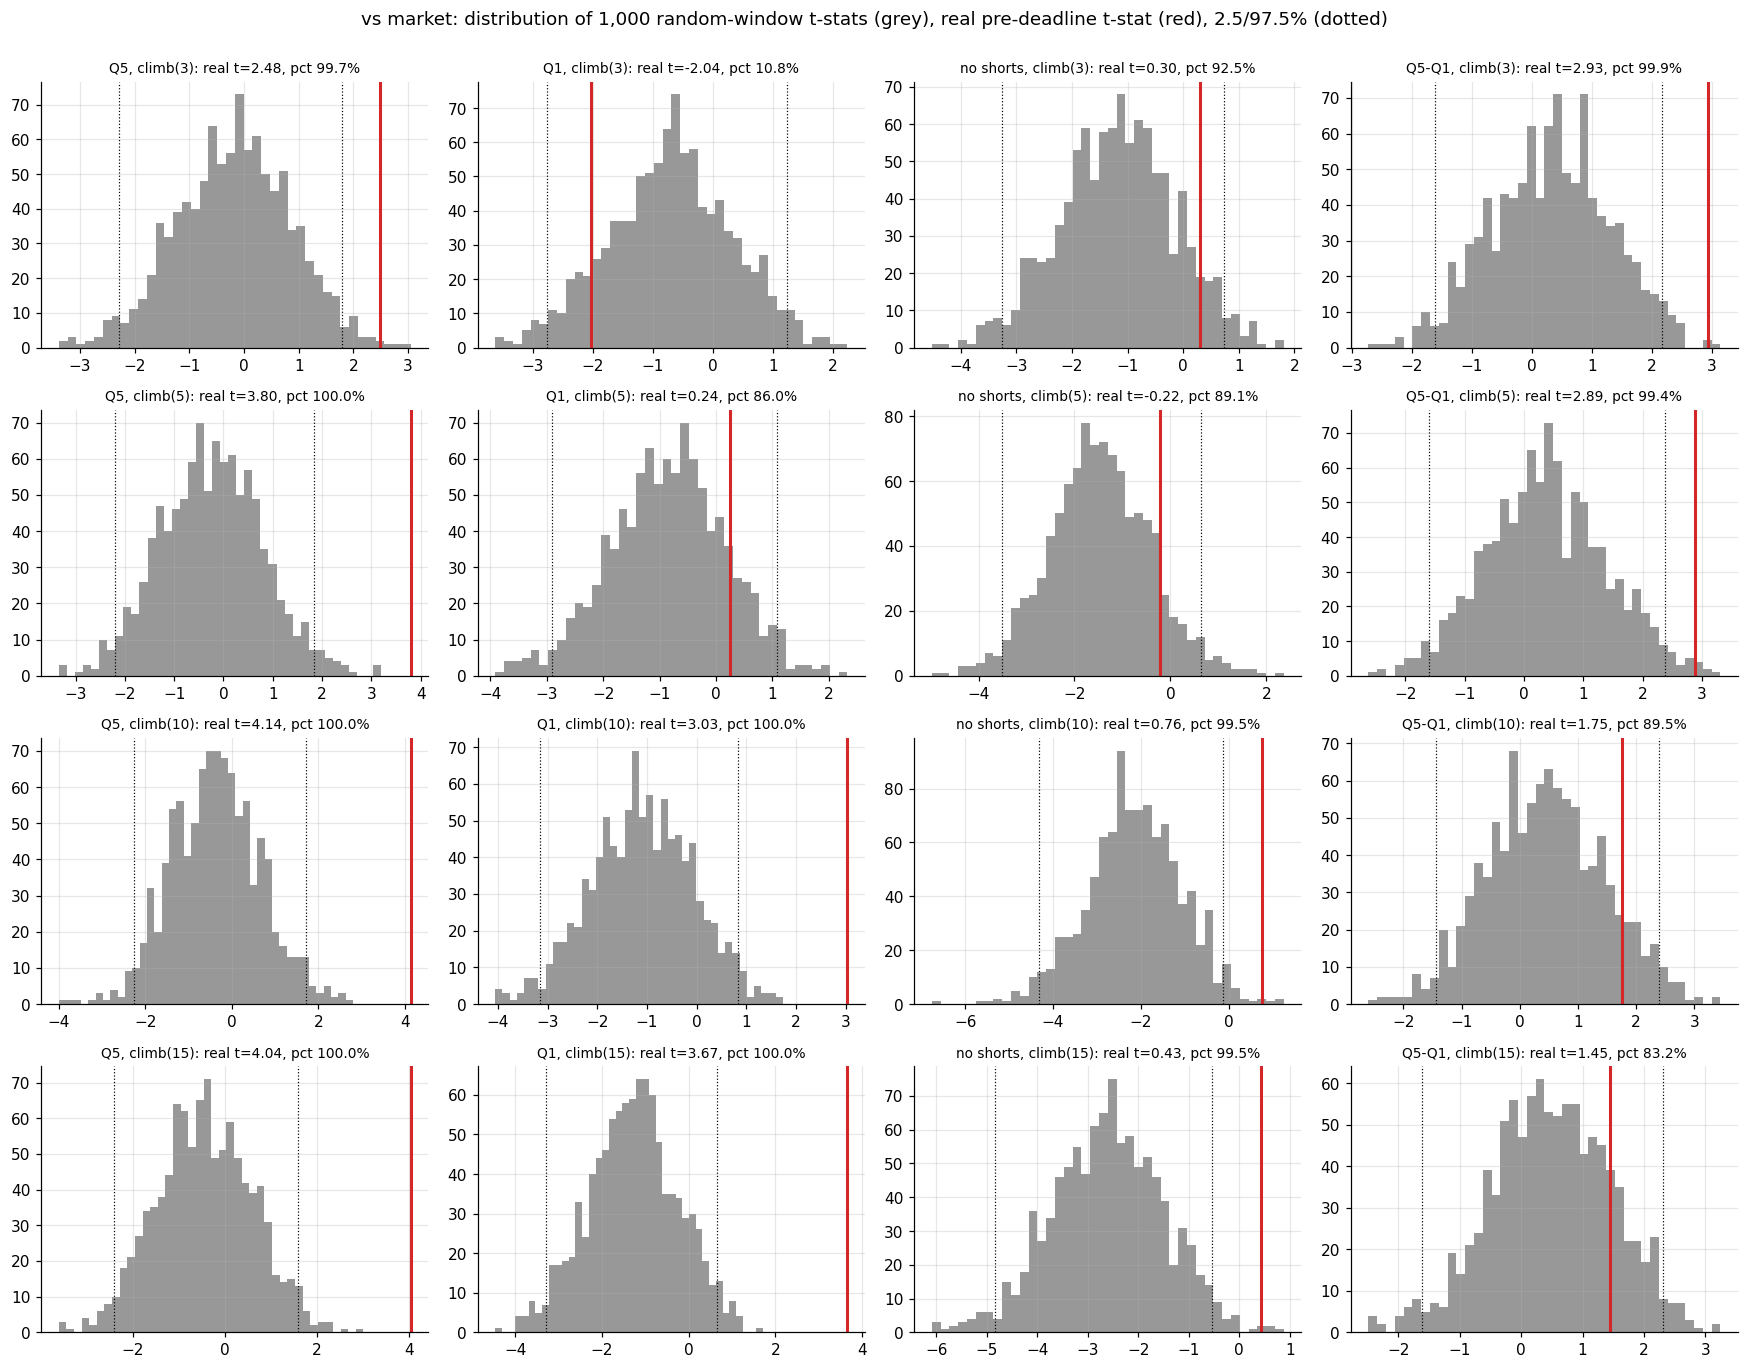

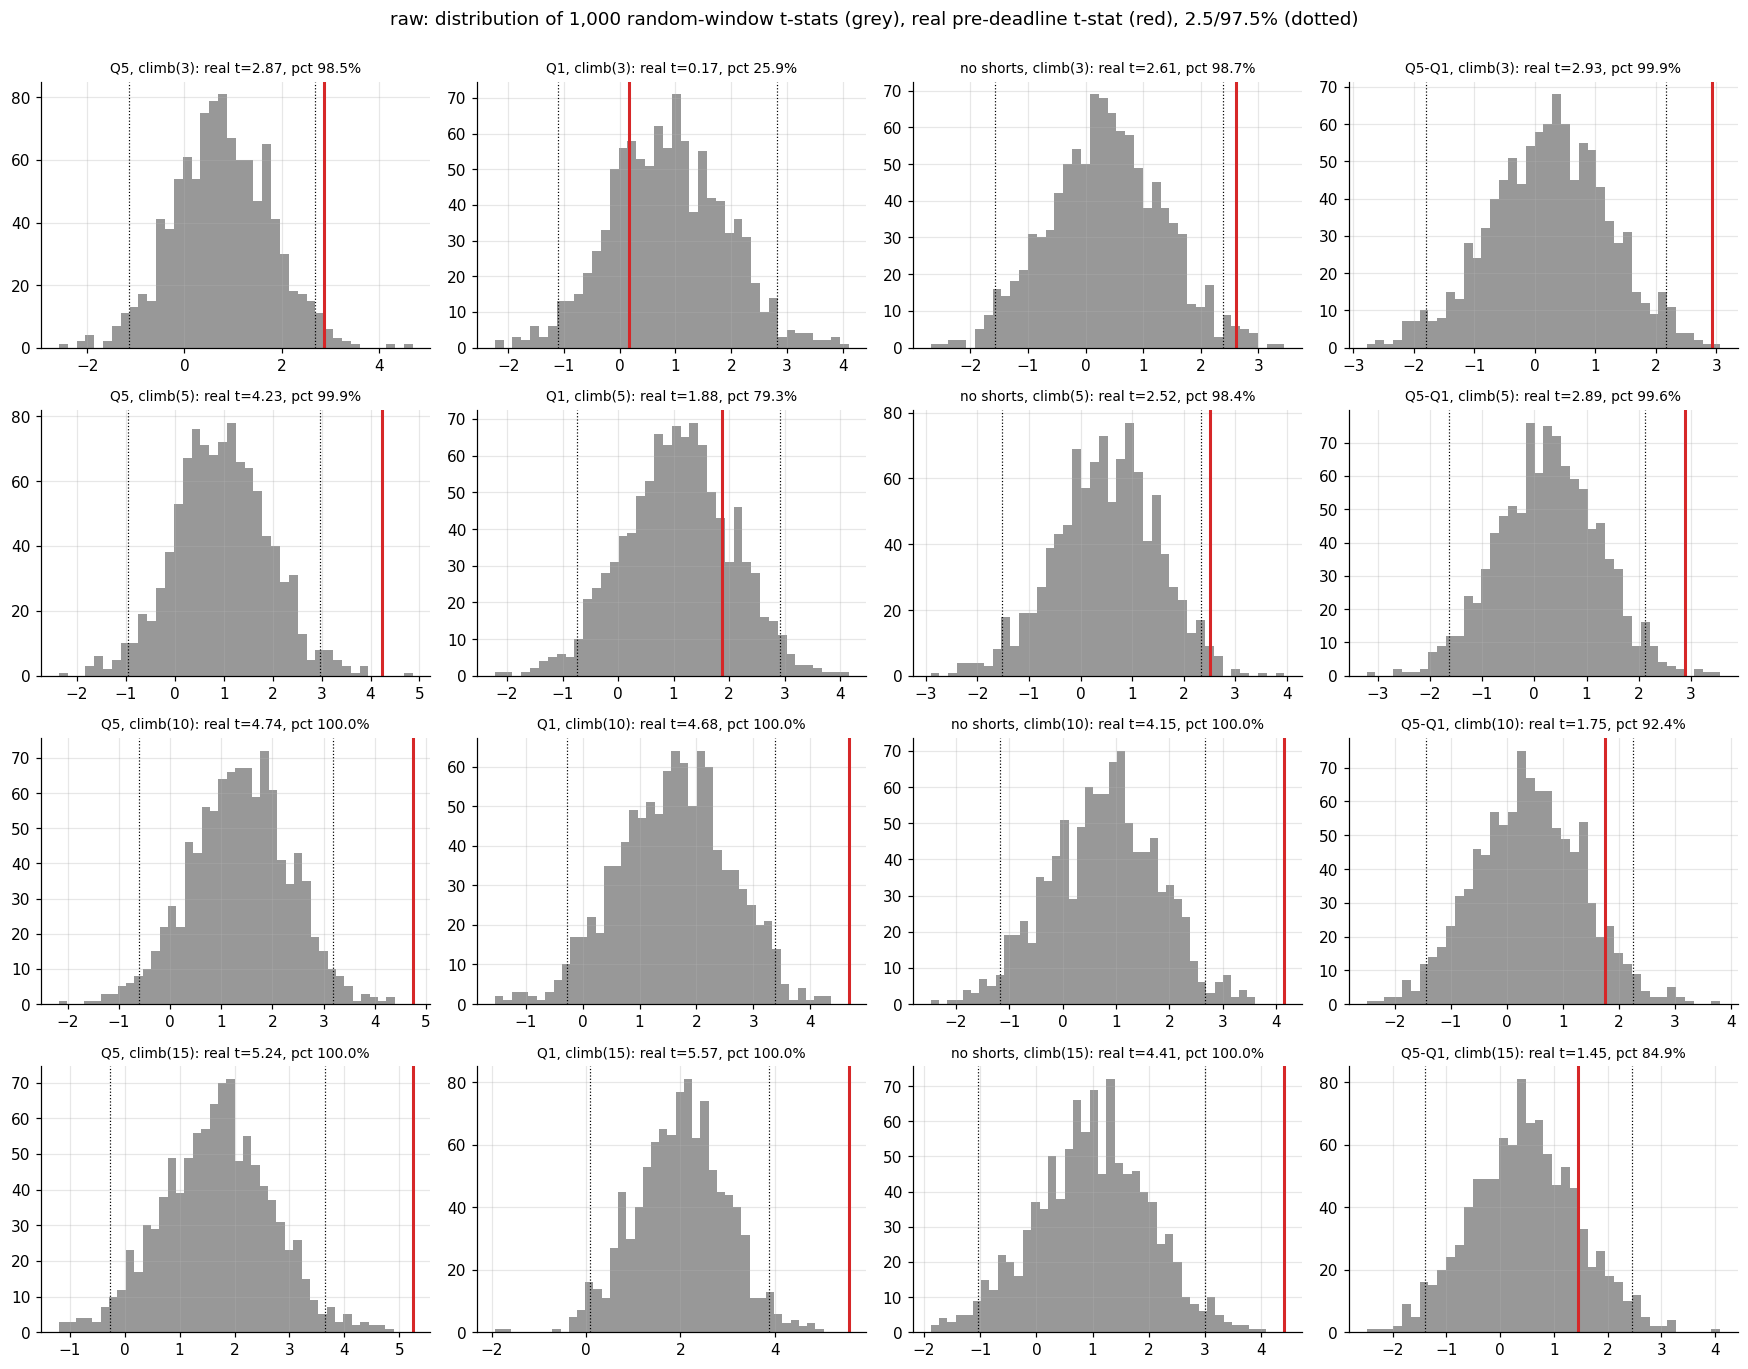

In [8]:
for kind, (real, null) in tres.items():
    fig, axes = plt.subplots(len(XT), len(BUCKETS), figsize=(16, 3.1 * len(XT)))
    for r_, x in enumerate(XT):
        for c_, g_ in enumerate(BUCKETS):
            a = axes[r_, c_]; nl = null[(g_, x)]; t_real = real[(g_, x)][0]
            a.hist(nl, bins=40, color="C7", alpha=.8)
            a.axvline(t_real, color="C3", lw=2)
            for q in [2.5, 97.5]: a.axvline(np.percentile(nl, q), color="k", ls=":", lw=.8)
            a.set_title(f"{g_}, climb({x}): real t={t_real:.2f}, pct {(nl < t_real).mean():.1%}", fontsize=9)
    fig.suptitle(f"{kind}: distribution of 1,000 random-window t-stats (grey), real pre-deadline t-stat (red), 2.5/97.5% (dotted)", y=1.0)
    plt.tight_layout(); plt.show()

**Interpretation.**
- **15 days before the deadline, Q5 is far outside the null.** Against the market, the Q5 portfolio's real t-stat is
  **4.04**. The 1,000 random-window t-stats average −0.44 with a 97.5th percentile of 1.58, so none of the 1,000
  random windows reaches the real one (p ≤ 0.001).
- **But Q1 is also outside it at 15 days** (t = 3.67, also beyond every random window), and Q5 − Q1 at 15 days is
  unremarkable (t = 1.45, 83rd percentile, p = 0.17). The 15-day climb is real, but it belongs to the pre-book-closure
  calendar for all shortable stocks, not to short covering. Only the no-shorts bucket, the smallest and least liquid
  stocks, does not share it (t = 0.43).
- **The short-covering part is the last 3–5 days.** There, Q1 is inside its null (t = −2.0 and 0.2) while Q5 is at the
  99.7th / 100th percentile (t = 2.5 and 3.8), and **Q5 − Q1 is at the 99.9th / 99.4th percentile (t = 2.9, p = 0.002 and 0.007)**.
- Raw returns tell the same story with everything shifted up by the market, since the null t-stats are centred above 0.
- Note that the portfolio mean weights each deadline date equally (Q5 15-day +144bp vs market), whereas section 3
  weights each event equally (+41bp). Days with many deadlines at once (peak AGM days) climb less than quieter days.

### 4c. Q5: t-stat by days to deadline
**What this does.** Section 4b run for every window length x = 1…15 on Q5 only. For each x: the real t-stat of the
Q5 portfolio's climb from the close of D−x to the close of D, against 1,000 cohort-level random windows of the same length.
The chart puts days to deadline on the x-axis, like the minutes-to-09:55 chart in the gotobi pitch. The red line is
the real t-stat; the grey band is the middle 95% of the 1,000 null t-stats (the line is their median).

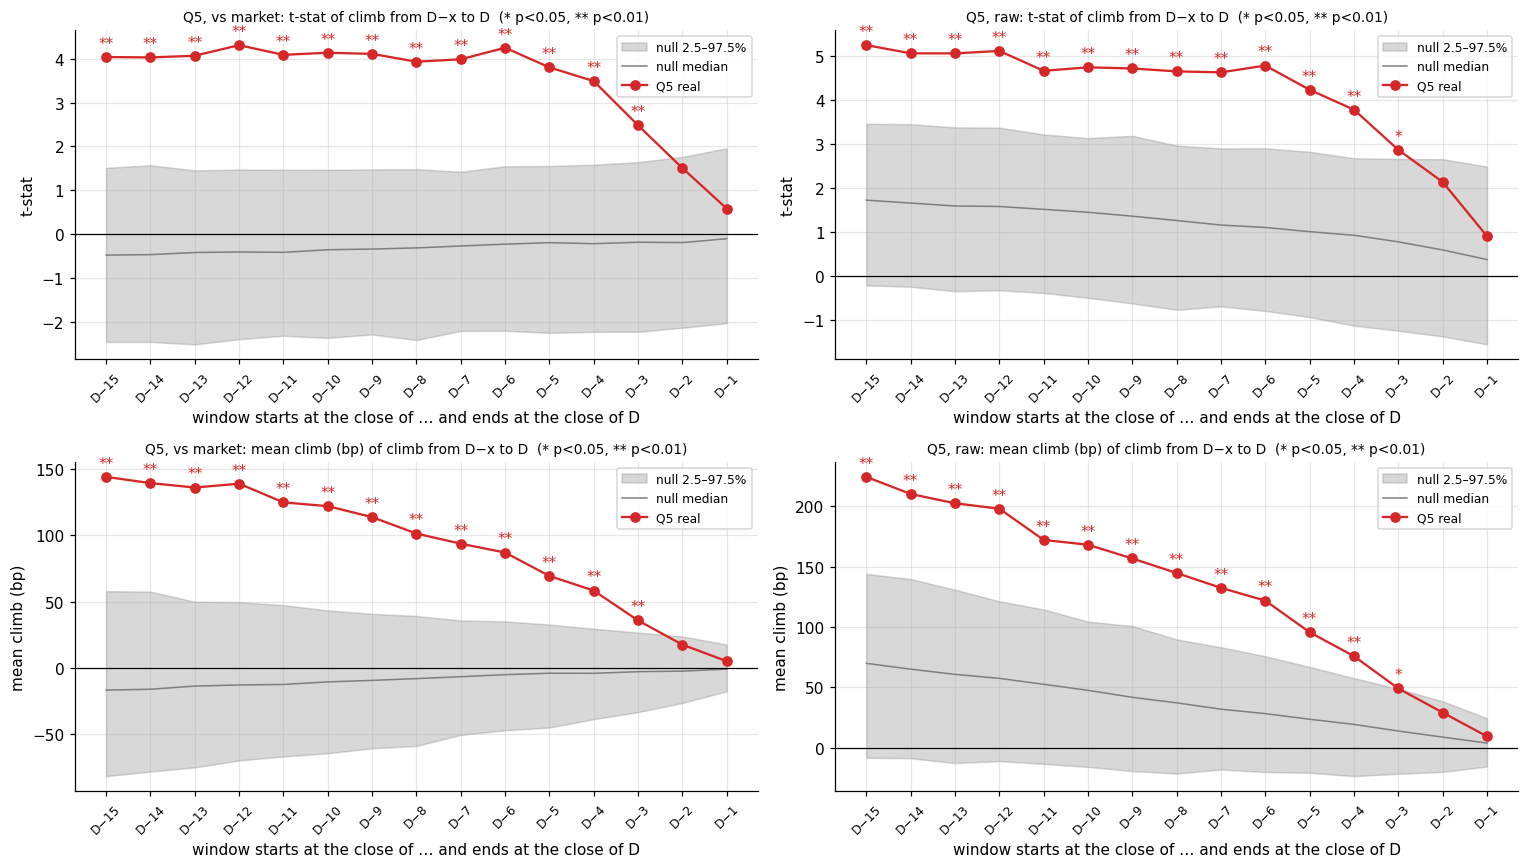


==== Q5, vs market
    real_mean_bp  real_t  null_t_median  null_t_97.5%  pct_rank  p_one_sided
x                                                                           
1          5.121   0.582         -0.104         1.957      74.3        0.258
2         17.601   1.505         -0.194         1.759      95.0        0.051
3         35.849   2.480         -0.186         1.641      99.8        0.003
4         58.382   3.488         -0.219         1.581     100.0        0.001
5         69.407   3.801         -0.196         1.552     100.0        0.001
6         87.079   4.249         -0.229         1.546     100.0        0.001
7         93.738   3.985         -0.271         1.420     100.0        0.001
8        101.389   3.931         -0.315         1.481     100.0        0.001
9        113.798   4.109         -0.341         1.473     100.0        0.001
10       122.062   4.135         -0.357         1.467     100.0        0.001
11       124.909   4.086         -0.416         1.466   

In [9]:
XS_ALL = np.arange(1, X_MAX + 1)
q5m = grp == "Q5"
def q5_t_all(CM, E, valid):
    # t-stat of the Q5 cohort portfolio for every x at once
    cl = CM[E + 1, J][:, None] - CM[(E + 1)[:, None] - XS_ALL[None, :], J[:, None]]
    out = np.empty(len(XS_ALL)); mu = np.empty(len(XS_ALL))
    for k in range(len(XS_ALL)):
        t_, m_, _ = tstat(coh_mean(cl[:, k], valid & q5m))
        out[k], mu[k] = t_, m_
    return out, mu

q5res = {}
for kind, CM in [("vs market", C_EW), ("raw", C_RAW)]:
    t_real, mu_real = q5_t_all(CM, D, ok_ev)
    nt, nm = np.empty((N_T_BOOT, X_MAX)), np.empty((N_T_BOOT, X_MAX))
    for b in range(N_T_BOOT):
        E = random_ends()[coh_idx]
        nt[b], nm[b] = q5_t_all(CM, E, VALID[E, J])
    q5res[kind] = (t_real, mu_real, nt, nm)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for c_, kind in enumerate(["vs market", "raw"]):
    t_real, mu_real, nt, nm = q5res[kind]
    for r_, (real, null, ylab) in enumerate([(t_real, nt, "t-stat"), (mu_real * 1e4, nm * 1e4, "mean climb (bp)")]):
        a = axes[r_, c_]
        lo, md_, hi = np.percentile(null, [2.5, 50, 97.5], axis=0)
        a.fill_between(-XS_ALL, lo, hi, color="C7", alpha=.3, label="null 2.5–97.5%")
        a.plot(-XS_ALL, md_, color="C7", lw=1, label="null median")
        a.plot(-XS_ALL, real, "o-", color="C3", label="Q5 real")
        p_ = ((null >= real).sum(0) + 1) / (len(null) + 1)
        for xx, yy, pp in zip(-XS_ALL, real, p_):
            if pp <= 0.01: a.annotate("**", (xx, yy), textcoords="offset points", xytext=(0, 6), ha="center", color="C3")
            elif pp <= 0.05: a.annotate("*", (xx, yy), textcoords="offset points", xytext=(0, 6), ha="center", color="C3")
        a.axhline(0, color="k", lw=.8)
        a.set_xticks(-XS_ALL); a.set_xticklabels([f"D−{x}" for x in XS_ALL], rotation=45, fontsize=8)
        a.set_xlabel("window starts at the close of … and ends at the close of D"); a.set_ylabel(ylab)
        a.set_title(f"Q5, {kind}: {ylab} of climb from D−x to D  (* p<0.05, ** p<0.01)", fontsize=9); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

for kind in q5res:
    t_real, mu_real, nt, nm = q5res[kind]
    tab = pd.DataFrame({"real_mean_bp": mu_real * 1e4, "real_t": t_real, "null_t_median": np.median(nt, 0),
                        "null_t_97.5%": np.percentile(nt, 97.5, 0), "pct_rank": (nt < t_real).mean(0) * 100,
                        "p_one_sided": ((nt >= t_real).sum(0) + 1) / (N_T_BOOT + 1)}, index=pd.Index(XS_ALL, name="x"))
    print(f"\n==== Q5, {kind}")
    print(tab.round(3).to_string())

**Interpretation.**
- **The red line leaves the null band at D−3 and stays out.** Against the market, the Q5 t-stat is 0.6 for the last
  day alone and 1.5 from D−2 (p = 0.05), crosses the null's 97.5th percentile at **D−3 (t = 2.5, p = 0.003)**, and is
  **3.5–4.3 from D−4 back to D−15** (beyond all 1,000 random windows every time). The null band stays centred near
  zero at every length, so this is not a property of 15-day windows in general.
- **Where the climb happens (mean path, vs market):** +5bp on D itself, +36bp by D−3, +87bp by D−6, +122bp by D−10,
  +144bp by D−15. The steepest stretch is **D−6 → D−2, about +16bp a day**. Before D−6 it rises about 5–6bp a day, and on
  the deadline day it is flat. That fits the covering flow: most of the short book is bought back between D−5 and D−1.
  On D the remaining ~30% is covered without moving the price, which is consistent with it being small and anticipated.
- **The t-stat plateaus from D−6 on.** Adding days further back adds return but also noise, so the signal-to-noise
  of the trade is best when you enter around **D−6 to D−4**.
- Raw returns show the same shape shifted up by the market (the raw null is centred at t ≈ 0.4–1.7).
- Caveat from 4b: at the longer lengths (x ≥ 10) Q1 is also outside its null, so the early part of the climb is
  shared with lightly shorted stocks. The part specific to heavy short interest is the last ~3–6 days.

### 4d. Q5 out to 50 days before the deadline
**What this does.** Section 4c stretched to x = 1…50. A window that starts before the signal date would contain the
day short pressure was measured on (look-ahead), so for this section **Q5 is re-formed on D−52** (published that
evening, tradable from the close of D−51). Random windows now avoid [D−50, D+25] around each stock's own deadlines.
Only the D−52 Q5 is plotted; black-edged points beat the random-window null at p ≤ 0.05 (null not drawn).

Note: a 50-day window before an ex-dividend deadline often contains the same stock's AGM deadline (and the drop after
it), since the two are typically 1–3 months apart. The events are not filtered for this.

Q5 formed on D-52: 2083 events; Q5 formed on D-17 (with a 50-day window available): 2266; overlap 1233


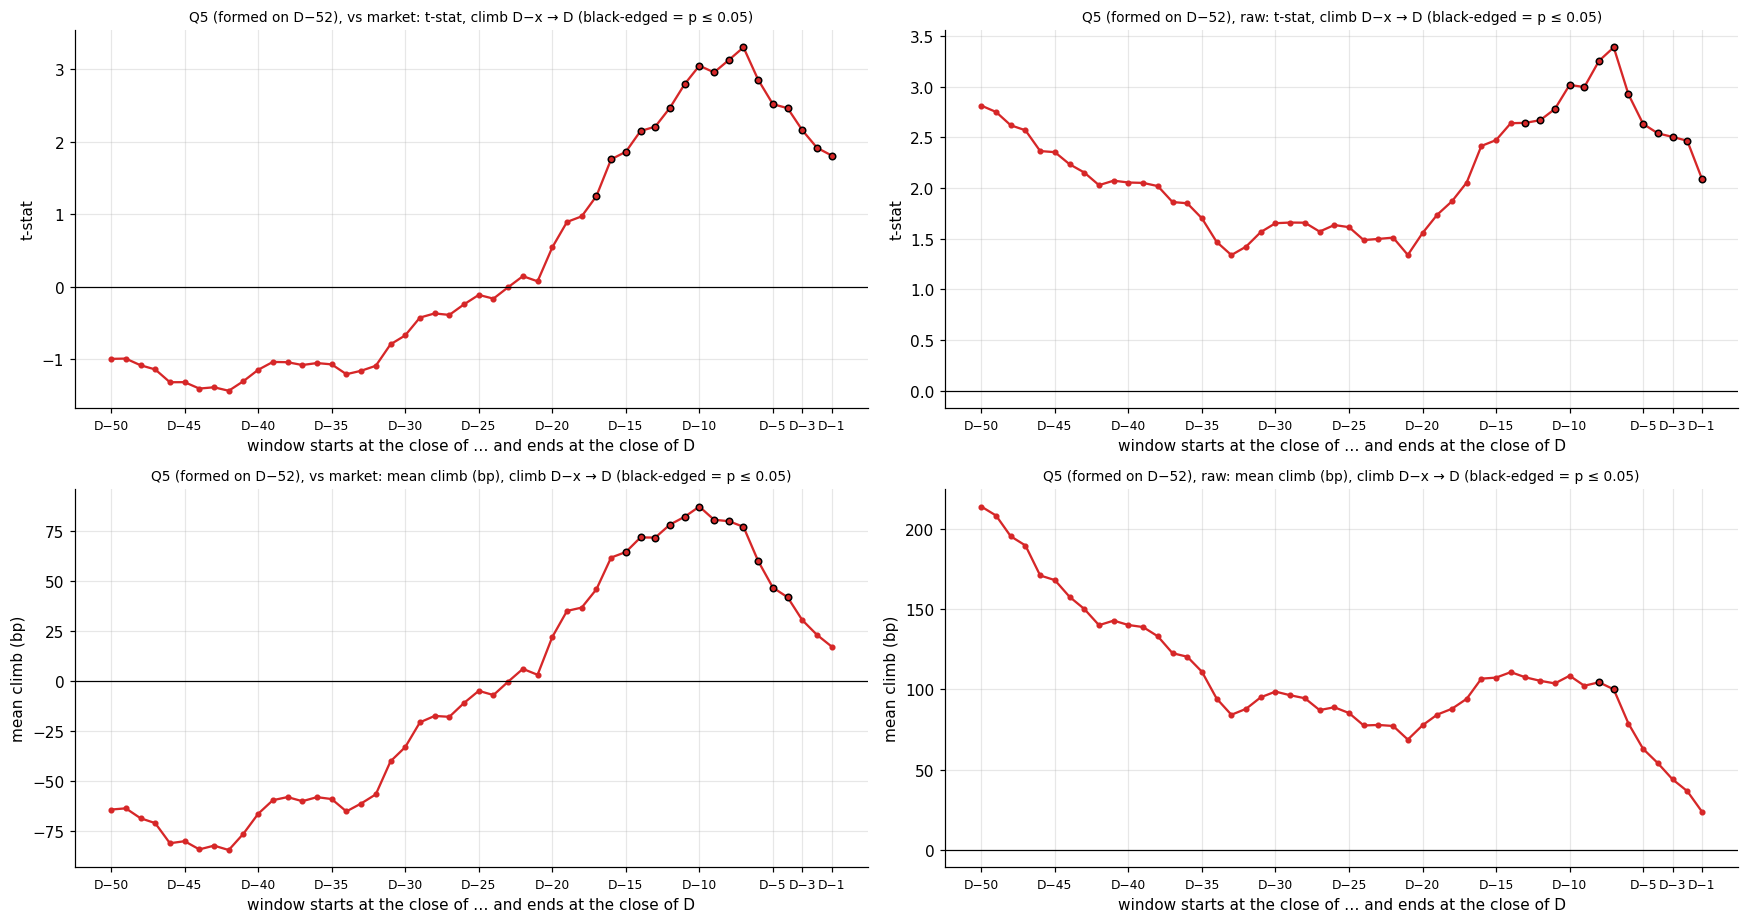


==== Q5 formed on D-52, vs market
    mean_bp      t  null_t_median  null_t_97.5%      p  D-17 Q5 t
x                                                                
1    17.205  1.807         -0.129         1.810  0.027      0.602
2    23.080  1.913         -0.108         1.836  0.023      1.593
3    30.464  2.156         -0.148         1.727  0.009      2.565
4    41.912  2.460         -0.230         1.627  0.004      3.564
5    46.747  2.514         -0.245         1.622  0.003      3.850
6    60.016  2.851         -0.265         1.589  0.002      4.319
8    79.992  3.122         -0.333         1.612  0.001      3.994
10   87.289  3.045         -0.340         1.556  0.001      4.119
12   78.270  2.464         -0.446         1.488  0.001      4.216
15   64.540  1.858         -0.526         1.565  0.009      3.950
20   22.011  0.541         -0.649         1.422  0.135      3.402
25   -4.931 -0.114         -0.781         1.285  0.259      3.353
30  -33.096 -0.672         -0.910        

In [10]:
XL = 50; SIG_L = XL + 2
XS_L = np.arange(1, XL + 1)
okL = (D - SIG_L >= 0) & TRADED[D, J] & np.roll(TRADED, XL, axis=0)[D, J] & (D - XL - 1 >= 0)
sL = np.clip(D - SIG_L, 0, T - 1)
dtcL = SB.values[sL, J] / ADV.values[sL, J]
hasL = okL & (SB.values[sL, J] > 0) & np.isfinite(dtcL)
qL = pd.Series(np.nan, index=ev.index)
qL[hasL] = pd.Series(dtcL[hasL], index=ev.index[hasL]).groupby(ev.year[hasL]).transform(quint)
q5L = (qL == 5).values
q5S = (grp == "Q5") & okL
print(f"Q5 formed on D-52: {q5L.sum()} events; Q5 formed on D-17 (with a 50-day window available): {q5S.sum()}; "
      f"overlap {(q5L & q5S).sum()}")

VALID_L = TRADED & np.roll(TRADED, XL, axis=0)
VALID_L[: XL + 1] = False
for d_, j_ in zip(D, J):
    VALID_L[max(d_ - XL, 0): min(d_ + 26, T), j_] = False

def random_ends_L():
    e = rng.integers(XL + 1, T - 1, n_coh)
    bad = (e >= D_coh - XL) & (e <= D_coh + 25)
    while bad.any():
        e[bad] = rng.integers(XL + 1, T - 1, bad.sum())
        bad = (e >= D_coh - XL) & (e <= D_coh + 25)
    return e

def t_all_L(CM, E, valid, mask):
    cl = CM[E + 1, J][:, None] - CM[(E + 1)[:, None] - XS_L[None, :], J[:, None]]
    t_, mu = np.empty(XL), np.empty(XL)
    for k in range(XL):
        t_[k], mu[k], _ = tstat(coh_mean(cl[:, k], valid & mask))
    return t_, mu

resL = {}
for kind, CM in [("vs market", C_EW), ("raw", C_RAW)]:
    real = {nm_: t_all_L(CM, D, okL, m_) for nm_, m_ in [("D-52", q5L), ("D-17", q5S)]}
    null = {nm_: (np.empty((N_T_BOOT, XL)), np.empty((N_T_BOOT, XL))) for nm_ in real}
    for b in range(N_T_BOOT):
        E = random_ends_L()[coh_idx]
        v_ = VALID_L[E, J]
        for nm_, m_ in [("D-52", q5L), ("D-17", q5S)]:
            null[nm_][0][b], null[nm_][1][b] = t_all_L(CM, E, v_, m_)
    resL[kind] = (real, null)

fig, axes = plt.subplots(2, 2, figsize=(16, 8.5))
for c_, kind in enumerate(["vs market", "raw"]):
    real, null = resL[kind]
    for r_, (i_, ylab, scale) in enumerate([(0, "t-stat", 1), (1, "mean climb (bp)", 1e4)]):
        a = axes[r_, c_]
        rl = real["D-52"][i_] * scale
        a.plot(-XS_L, rl, "o-", ms=3, color="C3")
        p_ = ((null["D-52"][i_] * scale >= rl).sum(0) + 1) / (N_T_BOOT + 1)
        sig_ = p_ <= 0.05
        a.scatter(-XS_L[sig_], rl[sig_], s=18, color="C3", edgecolor="k", zorder=5)
        a.axhline(0, color="k", lw=.8)
        ticks = [1, 3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
        a.set_xticks([-t for t in ticks]); a.set_xticklabels([f"D−{t}" for t in ticks], fontsize=8)
        a.set_xlabel("window starts at the close of … and ends at the close of D"); a.set_ylabel(ylab)
        a.set_title(f"Q5 (formed on D−52), {kind}: {ylab}, climb D−x → D (black-edged = p ≤ 0.05)", fontsize=9)
plt.tight_layout(); plt.show()

for kind in resL:
    real, null = resL[kind]
    tr_, mu_ = real["D-52"]; nt = null["D-52"][0]
    tab = pd.DataFrame({"mean_bp": mu_ * 1e4, "t": tr_, "null_t_median": np.median(nt, 0), "null_t_97.5%": np.percentile(nt, 97.5, 0),
                        "p": ((nt >= tr_).sum(0) + 1) / (N_T_BOOT + 1), "D-17 Q5 t": real["D-17"][0]}, index=pd.Index(XS_L, name="x"))
    print(f"\n==== Q5 formed on D-52, {kind}")
    print(tab.loc[[1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50]].round(3).to_string())

**Interpretation.**
- **The climb is the last ~10–15 trading days, not 50.** With the clean D−52 Q5 (vs market), every window from D−1 to
  D−15 is significant (p ≤ 0.03). The mean climb peaks at **+80–87bp for windows starting D−8 to D−10 (t ≈ 3.1)**.
  Windows starting further back shrink: D−15 +65bp (p = 0.009), D−20 +22bp (p = 0.14), D−30 −33bp, D−50 −64bp,
  none significant.
- **So before the climb, Q5 stocks lag the market.** From roughly D−50 to D−12 heavily shorted names drift down
  relative to the market (the short sellers are partly right, and a 50-day window before an ex-dividend deadline
  often contains the drop after the same stock's AGM deadline). Then, about two weeks out, they turn and climb into D.
- **Why the signal date matters.** Measured on D−17 (not plotted; see the table's last column), Q5's t-stat stays at
  3–4 all the way back to D−25 and ~1 at D−50. For windows starting before D−17 that is look-ahead: stocks that rallied from D−50 to D−17
  attracted new retail shorts, so they were *selected into* Q5 by the rally. The clean line removes that.
- **A fresher signal gives a sharper effect near D.** Over the last 5 days, the D−17 Q5 has t = 3.9 against 2.5 for the
  D−52 Q5. A short balance measured closer to the deadline is a better guide to how much will actually be covered.
- **Raw** (not market-adjusted), the clean Q5 is significant only for windows starting D−1 to D−12. Beyond that the
  market's own drift swamps it: the raw null is centred well above zero, so a raw t of 2–2.8 at D−20 to D−50 is
  not significant.
- **What this means for the trade:** measure short pressure as late as the data allows (D−7 still leaves room to
  enter at D−6), and hold only about the last 1–2 weeks.

### 4e. Day by day: is each single day's move significant?
**What this does.** Sections 4c–4d plot the *cumulative* climb from D−x to D, so a big move on one day stays inside every
longer window. Here each point is the Q5 portfolio's return **on that day alone** (close of the previous day to
close of that day), against the same 1,000 cohort-level random windows at the same offset. Solid: Q5 formed on D−52
(clean for every day shown). Dashed: Q5 formed on D−17, shown only from D−15 on (where it is clean).

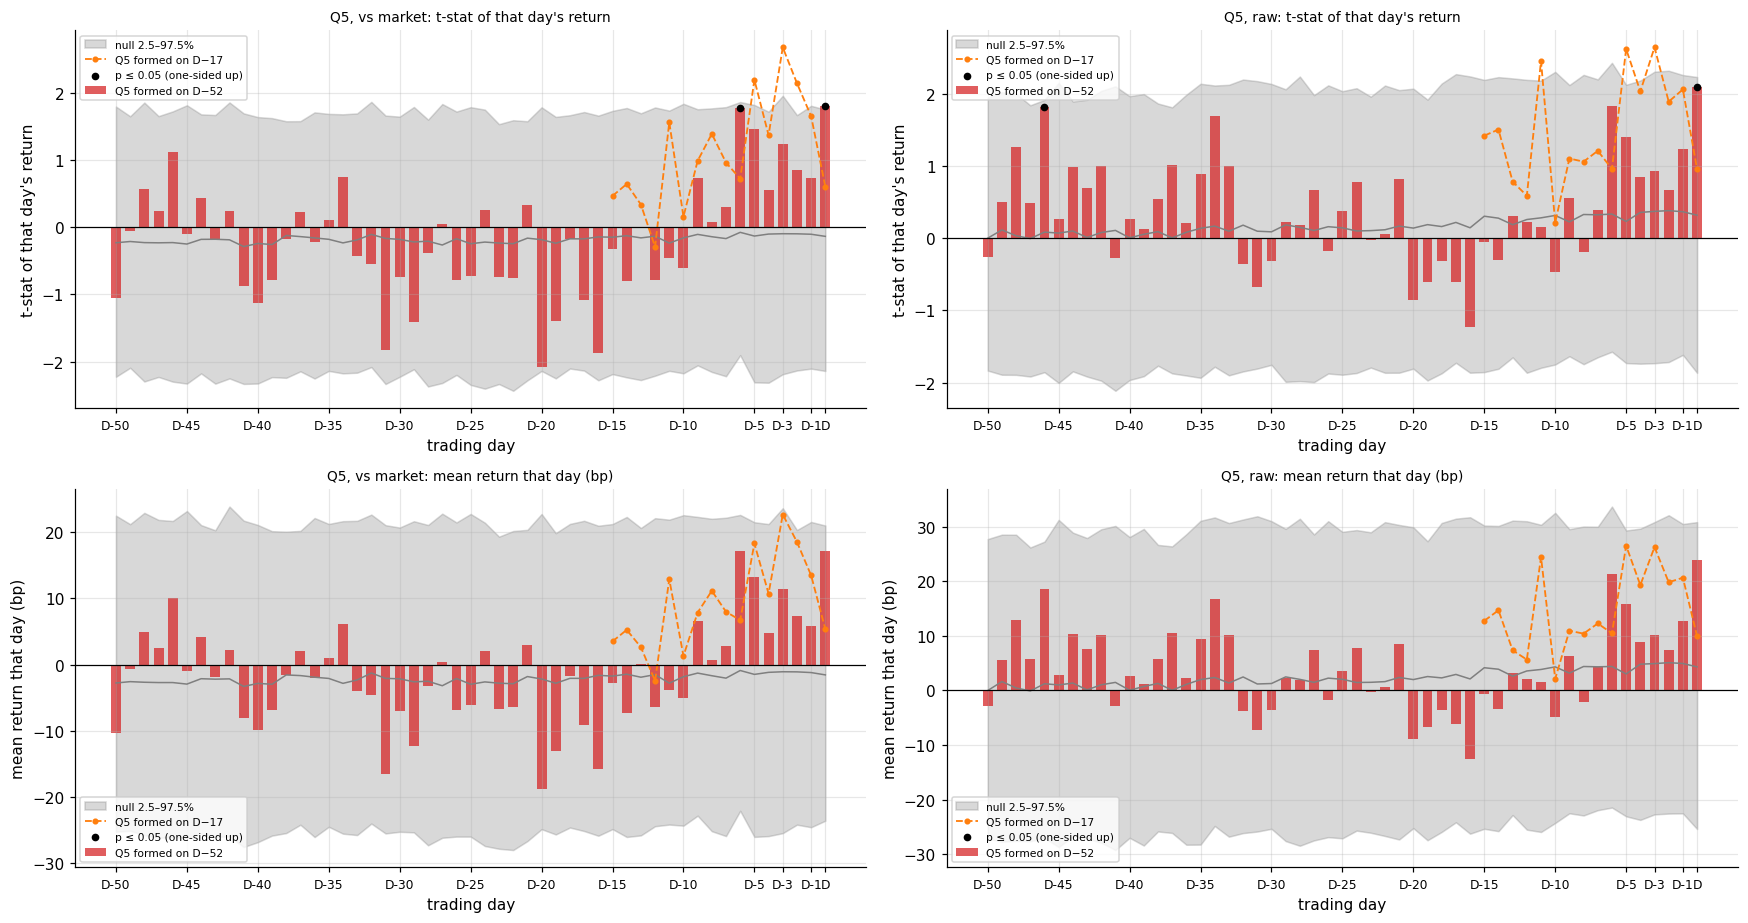


==== Q5 single-day returns, vs market (p one-sided: real >= null)
     D-52 bp  D-52 t  D-52 p  D-17 bp  D-17 t  D-17 p
day                                                  
-20  -18.916  -2.082   0.972      NaN     NaN     NaN
-19  -13.055  -1.401   0.885      NaN     NaN     NaN
-18   -1.671  -0.176   0.500      NaN     NaN     NaN
-17   -9.160  -1.079   0.819      NaN     NaN     NaN
-16  -15.886  -1.875   0.945      NaN     NaN     NaN
-15   -2.757  -0.319   0.561    3.501   0.466   0.265
-14   -7.316  -0.802   0.759    5.243   0.642   0.205
-13    0.077   0.009   0.440    2.625   0.337   0.283
-12   -6.490  -0.790   0.750   -2.480  -0.293   0.539
-11   -3.921  -0.459   0.605   12.908   1.560   0.026
-10   -5.099  -0.614   0.683    1.297   0.156   0.360
-9     6.599   0.731   0.211    7.868   0.987   0.111
-8     0.698   0.078   0.416   11.149   1.388   0.058
-7     2.831   0.306   0.320    7.983   0.961   0.123
-6    17.145   1.771   0.030    6.707   0.720   0.188
-5    13.270   

In [11]:
OFFS = np.arange(-XL, 1)                    # days D-50 .. D
def day_t(CM, A, valid, mask):
    # t-stat and mean of the cohort portfolio's single-day return on day A+o, for every offset o
    t_, mu = np.empty(len(OFFS)), np.empty(len(OFFS))
    for k, o in enumerate(OFFS):
        v = CM[np.clip(A + o + 1, 0, T), J] - CM[np.clip(A + o, 0, T), J]
        t_[k], mu[k], _ = tstat(coh_mean(v, valid & mask))
    return t_, mu

resD = {}
for kind, CM in [("vs market", C_EW), ("raw", C_RAW)]:
    real = {nm_: day_t(CM, D, okL, m_) for nm_, m_ in [("D-52", q5L), ("D-17", q5S)]}
    null = {nm_: (np.empty((N_T_BOOT, len(OFFS))), np.empty((N_T_BOOT, len(OFFS)))) for nm_ in real}
    for b in range(N_T_BOOT):
        E = random_ends_L()[coh_idx]
        v_ = VALID_L[E, J]
        for nm_, m_ in [("D-52", q5L), ("D-17", q5S)]:
            null[nm_][0][b], null[nm_][1][b] = day_t(CM, E, v_, m_)
    resD[kind] = (real, null)

fig, axes = plt.subplots(2, 2, figsize=(16, 8.5))
clean17 = OFFS >= -15
for c_, kind in enumerate(["vs market", "raw"]):
    real, null = resD[kind]
    for r_, (i_, ylab, scale) in enumerate([(0, "t-stat of that day's return", 1), (1, "mean return that day (bp)", 1e4)]):
        a = axes[r_, c_]
        nl = null["D-52"][i_] * scale
        lo, md_, hi = np.percentile(nl, [2.5, 50, 97.5], axis=0)
        a.fill_between(OFFS, lo, hi, color="C7", alpha=.3, label="null 2.5–97.5%")
        a.plot(OFFS, md_, color="C7", lw=1)
        rl = real["D-52"][i_] * scale
        a.bar(OFFS, rl, color="C3", alpha=.75, width=.7, label="Q5 formed on D−52")
        a.plot(OFFS[clean17], real["D-17"][i_][clean17] * scale, "o--", ms=3, color="C1", lw=1.2, label="Q5 formed on D−17")
        p_hi = ((nl >= rl).sum(0) + 1) / (N_T_BOOT + 1)
        sig_ = p_hi <= 0.05
        a.scatter(OFFS[sig_], rl[sig_], s=16, color="k", zorder=5, label="p ≤ 0.05 (one-sided up)")
        a.axhline(0, color="k", lw=.8)
        ticks = [-50, -45, -40, -35, -30, -25, -20, -15, -10, -5, -3, -1, 0]
        a.set_xticks(ticks); a.set_xticklabels([f"D{t}" if t else "D" for t in ticks], fontsize=8)
        a.set_xlabel("trading day"); a.set_ylabel(ylab)
        a.set_title(f"Q5, {kind}: {ylab}", fontsize=9); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

for kind in resD:
    real, null = resD[kind]
    rows = []
    for nm_ in ["D-52", "D-17"]:
        t_, mu_ = real[nm_]; nt = null[nm_][0]
        p_ = ((nt >= t_).sum(0) + 1) / (N_T_BOOT + 1)
        rows.append(pd.DataFrame({f"{nm_} bp": mu_ * 1e4, f"{nm_} t": t_, f"{nm_} p": p_}, index=pd.Index(OFFS, name="day")))
    tb = pd.concat(rows, axis=1)
    tb.loc[tb.index < -15, ["D-17 bp", "D-17 t", "D-17 p"]] = np.nan
    print(f"\n==== Q5 single-day returns, {kind} (p one-sided: real >= null)")
    print(tb.loc[list(range(-20, 1))].round(3).to_string())
    for nm_, lo_ in [("D-52", -50), ("D-17", -15)]:
        sub = tb.loc[lo_:, f"{nm_} p"]
        print(f"  {nm_}: days with p <= 0.05: {[int(d) for d in sub.index[sub <= 0.05]]}")

**Interpretation.**
- **The climb lives in the last five days before D.** With Q5 formed on D−17 (vs market), the days that are significant
  on their own are **D−5 (+18bp, t = 2.2), D−3 (+23bp, t = 2.7), D−2 (+19bp, t = 2.1) and D−1 (+13bp, t = 1.7)**, all
  p ≤ 0.03, plus D−11 (+13bp). Every day from D−9 to D−1 is positive. The deadline day itself is not significant (+5bp).
- **Before about D−10 there is nothing.** The single-day returns hover around zero inside the null band. With the D−52
  Q5 they are mostly slightly *negative* from D−35 to D−10 (Q5 lagging the market, as in 4d), and only D−6 and D stand out.
- **So the cumulative 4c–4d charts were carrying these few days forward.** Day by day, the signal switches on around D−5,
  when the short book starts draining fast (71% left on D−5 → 2% on D), and it adds up to about +80bp.
- 21 days are tested, so one "significant" day could be chance at 5%. Four of the last five days is not.

## 5. Is it these dates? A stress test
**What this does.** (a) **Calendar shift**: keep the same Q5 and Q1 stocks but slide the return window so it ends
k = −40…+40 trading days from D, and recompute the Q5−Q1 climb(5) and climb(15). If the climb is about the deadline,
k = 0 should stand out. (Re-sorting on shifted dates does not work here: a signal date that lands just after a real
deadline sees short balances that were just forced to zero.)
(b) **Heavy tails**: trimmed, winsorised and median versions and a sign test. (c) **Confounds**: regress climb(x) on
short-pressure rank with size, year and reason controls plus the stock's own momentum over the 20 days before the
window, errors clustered by deadline date. (d) **Stability**: by year, by reason, by size, in-sample vs out-of-sample.

Q5-Q1 climb(5): real 36.9bp | other windows mean -15.1bp, range [-99.1, 32.2] | rank 1/81


   Q5 alone climb(5): real 49.3bp | other windows mean -20.1bp | rank 1/81 | best other k = -1
Q5-Q1 climb(15): real -30.0bp | other windows mean -43.9bp, range [-197.3, 55.9] | rank 40/81


   Q5 alone climb(15): real 41.1bp | other windows mean -59.2bp | rank 1/81 | best other k = -1


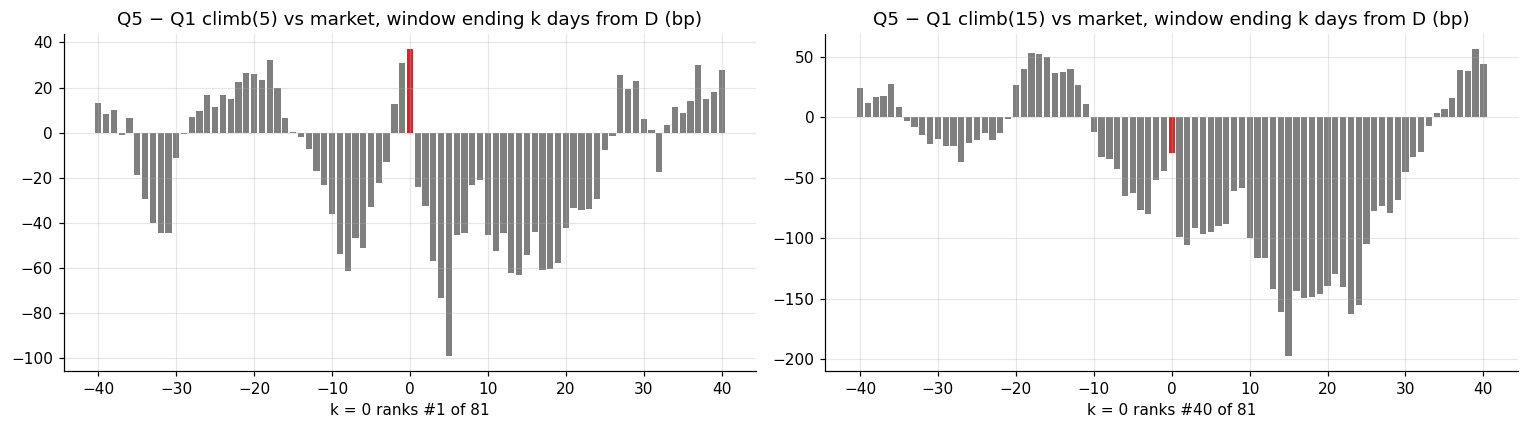

In [12]:
def shifted(k, x, g_):
    # same stocks (real D-17 quintile membership), return window moved to end at D+k
    m = (ev.grp == g_).values
    Dk, J_ = D[m] + k, J[m]
    ok = (Dk - x >= 0) & (Dk + 1 < T)
    Dk, J_ = Dk[ok], J_[ok]
    good = TRADED[Dk, J_] & TRADED[Dk - x, J_]
    return np.mean((C_EW[Dk + 1, J_] - C_EW[Dk + 1 - x, J_])[good]) * 1e4

ks = np.arange(-40, 41)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, x in zip(ax, [5, 15]):
    v = np.array([shifted(k, x, "Q5") - shifted(k, x, "Q1") for k in ks])
    a.bar(ks, v, color=np.where(ks == 0, "C3", "C7"))
    rank = int((v >= v[ks == 0][0]).sum())
    a.set_title(f"Q5 − Q1 climb({x}) vs market, window ending k days from D (bp)")
    a.set_xlabel(f"k = 0 ranks #{rank} of {len(ks)}")
    rest = np.delete(v, 40)
    print(f"Q5-Q1 climb({x}): real {v[40]:.1f}bp | other windows mean {rest.mean():.1f}bp, range [{rest.min():.1f}, {rest.max():.1f}] | rank {rank}/81")
    q5 = np.array([shifted(k, x, "Q5") for k in ks]); r5 = int((q5 >= q5[40]).sum())
    print(f"   Q5 alone climb({x}): real {q5[40]:.1f}bp | other windows mean {np.delete(q5, 40).mean():.1f}bp | rank {r5}/81 "
          f"| best other k = {ks[np.argmax(np.where(ks == 0, -1e9, q5))]:+d}")
plt.tight_layout(); plt.show()

In [13]:
XSTAR = [5, 15]
tr = lambda s, q: s[(s > s.quantile(q)) & (s < s.quantile(1 - q))]
wz = lambda s, q: s.clip(s.quantile(q), s.quantile(1 - q))
for x in XSTAR:
    real, null = res[("vs market", "same stock")]
    a = pd.Series(CL["vs market"][(ev.grp == "Q5").values, x - 1]).dropna() * 1e4
    b = pd.Series(CL["vs market"][(ev.grp == "Q1").values, x - 1]).dropna() * 1e4
    print(f"(b) climb({x}) vs market, Q5 n={len(a)}: mean {a.mean():+.1f} | 5% trimmed {tr(a, .05).mean():+.1f} | "
          f"5% winsorised {wz(a, .05).mean():+.1f} | median {a.median():+.1f} (Q1 median {b.median():+.1f}) | "
          f"share up {(a > 0).mean():.1%} vs Q1 {(b > 0).mean():.1%}, sign-test p {st.binomtest(int((a > 0).sum()), len(a)).pvalue:.4f}")

mom = C_EW[D - X_MAX, J] - C_EW[D - X_MAX - 20, J]     # stock's own 20-day return ending the day before the climb window
d0 = ev.assign(mom=mom * 1e4, lsize=np.log(ev["size"]))
d0 = d0[d0.grp != "no shorts"].copy()
d0["dtc_rank"] = d0.groupby("year").dtc.rank(pct=True)
for x in XSTAR:
    d0["y"] = CL["vs market"][d0.index.values, x - 1] * 1e4
    dd = d0.dropna(subset=["y", "mom", "lsize"])
    f = smf.ols("y ~ dtc_rank + lsize + mom + C(year) + C(why)", dd).fit(cov_type="cluster", cov_kwds={"groups": dd.Ddate.factorize()[0]})
    print(f"(c) climb({x}): dtc_rank coef {f.params['dtc_rank']:+.1f}bp (top vs bottom of the cross-section), t={f.tvalues['dtc_rank']:.2f}; "
          f"momentum coef {f.params['mom']:+.3f}, t={f.tvalues['mom']:.2f}; n={int(f.nobs)}")

(b) climb(5) vs market, Q5 n=2277: mean +49.7 | 5% trimmed +29.3 | 5% winsorised +41.3 | median +8.2 (Q1 median -24.5) | share up 51.2% vs Q1 46.1%, sign-test p 0.2578
(b) climb(15) vs market, Q5 n=2277: mean +41.1 | 5% trimmed +10.2 | 5% winsorised +33.7 | median -34.6 (Q1 median -11.2) | share up 48.1% vs Q1 49.0%, sign-test p 0.0715
(c) climb(5): dtc_rank coef +41.0bp (top vs bottom of the cross-section), t=2.08; momentum coef +0.028, t=2.95; n=11409


(c) climb(15): dtc_rank coef -29.6bp (top vs bottom of the cross-section), t=-0.83; momentum coef +0.057, t=2.79; n=11409


In [14]:
def by(col_, x):
    out = []
    for key, g in ev[ev.grp.isin(["Q5", "Q1"])].groupby(col_):
        row = {col_: key}
        for g_ in ["Q5", "Q1"]:
            m = (g.grp == g_).values
            mu, se = clustered_mean(CL["vs market"][g.index.values[m], x - 1], g.Ddate.values[m])
            row[f"{g_} bp"], row[f"{g_} t"], row[f"{g_} n"] = mu * 1e4, mu / se, m.sum()
        out.append(row)
    return pd.DataFrame(out).set_index(col_).round(2)

ev["size_t"] = pd.qcut(ev["size"].rank(method="first"), 3, labels=["small", "mid", "large"])
for c_ in ["year", "oos", "why", "size_t"]:
    print(f"\n==== climb(15) and climb(5) vs market, by {c_}")
    print(pd.concat({"climb(15)": by(c_, 15), "climb(5)": by(c_, 5)}, axis=1).to_string())


==== climb(15) and climb(5) vs market, by year
     climb(15)                               climb(5)                             
         Q5 bp  Q5 t Q5 n   Q1 bp  Q1 t Q1 n    Q5 bp  Q5 t Q5 n  Q1 bp  Q1 t Q1 n
year                                                                              
2018      9.56  0.16  250  132.11  3.94  249    26.09  0.87  250  28.61  1.54  249
2019     98.17  1.12  245   26.24  0.86  244    31.47  0.77  245   6.33  0.32  244
2020    -46.28 -0.64  244  -63.09 -1.22  244    50.89  1.02  244 -38.08 -1.07  244
2021     44.21  0.69  253   68.91  1.09  252    53.32  1.31  253  51.73  2.56  252
2022     30.71  0.47  264  136.89  2.54  263    48.85  1.62  264  45.84  1.40  263
2023     19.08  0.43  257   18.13  0.50  257    24.59  1.03  257  19.30  0.78  257
2024    136.22  1.59  265   58.08  1.10  264   112.81  3.11  265  10.58  0.42  264
2025      6.63  0.12  274  130.90  2.91  273    56.54  1.98  274  35.49  1.13  273
2026     71.20  0.51  235  124.42  2.02

**Interpretation.**
- **(a) It is these dates.** For the same stocks, Q5 − Q1 climb(5) is +37bp when the window ends on D, the
  **highest of all 81 windows** (other windows average −15bp, max +32bp). Q5 alone also ranks #1 of 81; the runner-up
  is the window ending on D−1, which overlaps the real one. At the 15-day horizon the real date is unremarkable
  (Q5 − Q1 ranks #40 of 81), which confirms the longer climb is not about short covering.
- **(b) Fat right tail.** Q5 climb(5) averages +50bp, but the 5%-trimmed mean is +29bp and the median only +8bp.
  Part of the effect is a minority of squeezes (strings of limit-up days in heavily shorted names), and these are
  real prices, not bad data. The gap survives in medians (Q5 +8bp vs Q1 −25bp), and 51% of Q5 events rise vs 46% of Q1.
- **(c) Not momentum or size.** Controlling for size, the stock's own prior 20-day return, year and event type, the
  top-vs-bottom short-pressure spread in climb(5) is +41bp (t = 2.1). For climb(15) it is −30bp (t = −0.8).
- **(d) Stability.** Q5 climb(5) versus the market is positive in **all nine years** (+25 to +113bp), but only 2024 and
  2025 are significant on their own. It is +39bp (t = 2.6) in 2018–23 and +70bp (t = 2.6) in 2024–26, so it is not
  fading. It is strongest for ex-dividend deadlines (+74bp, t = 3.1), present for AGMs (+39bp, t = 2.2), and lives in
  **mid and large caps** (+58bp and +66bp), not small caps (−15bp).

## 6. Is the climb tradeable? (unhedged)
**What this does.** Buy the liquid names (≥ NT$20m/day turnover) of a group at the close of D−x and sell at the
close of D, **unhedged**: no beta estimate is needed, and you carry the market. One equal-weighted portfolio per
deadline date. The P&L is net of 55bp for stock (30bp sell tax + commission + slippage) or 20bp for single-stock
futures (the same stock returns charged the futures cost; futures track the stock at 0.98 correlation over this
window, and the ex-dividend date always falls after D).

The same trade in **Q1** and in **no-shorts** stocks is the control. Those stocks see the same calendar and the
same market, but little or no forced buying. **Q5 − Q1** isolates the part of the P&L that comes from short covering.

                                     hit          net_bp               t        
period                           2018-23 2024-26 2018-23 2024-26 2018-23 2024-26
version                       x                                                 
Q5 stock                      1     0.40    0.40  -48.05  -23.84   -3.86   -0.94
                              2     0.46    0.45  -32.75   23.83   -1.91    0.70
                              3     0.49    0.45   -5.01   30.13   -0.23    0.76
                              5     0.55    0.53   37.52   69.87    1.27    1.42
                              8     0.56    0.54   45.72  152.58    1.18    2.20
                              10    0.58    0.59   74.11  184.65    1.63    2.32
                              15    0.60    0.58  149.15  212.77    2.70    2.21
Q5 futures                    1     0.48    0.47  -13.05   11.16   -1.05    0.44
                              2     0.53    0.49    2.25   58.83    0.13    1.73
                            

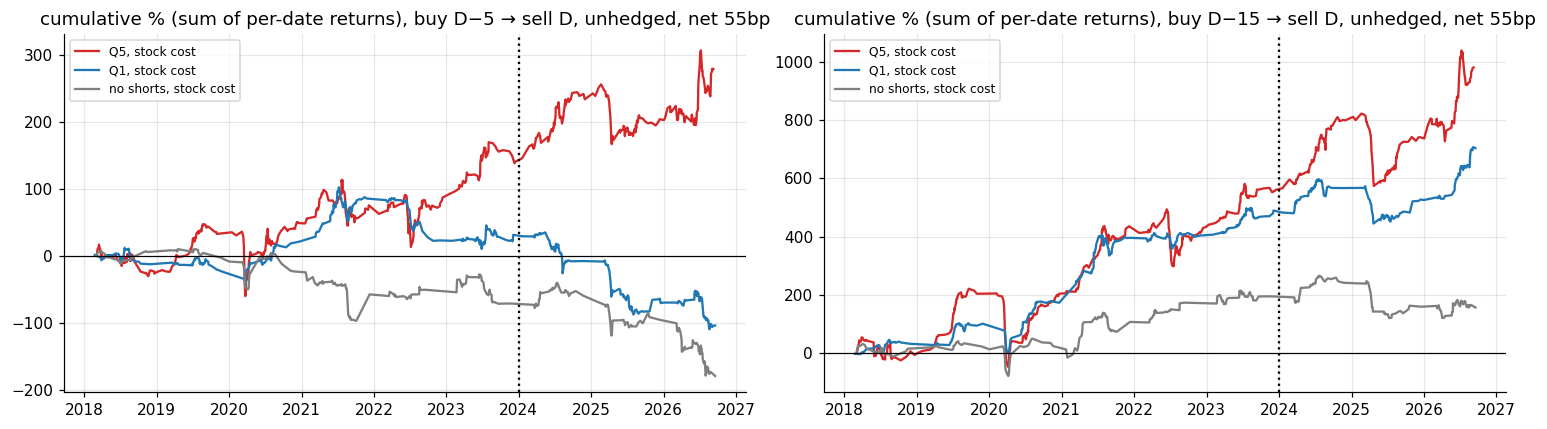

In [15]:
liq = (ev["size"] >= MIN_VAL20).values
def book(g_, x, pm):
    m = (ev.grp == g_).values & liq & pm & ok_ev
    return pd.Series(C_RAW[D[m] + 1, J[m]] - C_RAW[D[m] + 1 - x, J[m]]).groupby(ev.Ddate.values[m]).mean()

def line(r, cost):
    r = r.dropna() - cost / 1e4
    return dict(dates=len(r), net_bp=r.mean() * 1e4, t=r.mean() / r.std() * np.sqrt(len(r)), hit=(r > 0).mean(),
                worst_bp=r.min() * 1e4)

rows = []
for x in [1, 2, 3, 5, 8, 10, 15]:
    for per, pm in [("2018-23", ~ev.oos.values), ("2024-26", ev.oos.values)]:
        q5, q1, ns = book("Q5", x, pm), book("Q1", x, pm), book("no shorts", x, pm)
        for lab_, r, cost in [("Q5 stock", q5, COST_STOCK_BPS), ("Q5 futures", q5, COST_FUT_BPS),
                              ("Q1 stock (control)", q1, COST_STOCK_BPS), ("no-shorts stock (control)", ns, COST_STOCK_BPS),
                              ("Q5 - Q1 gross (covering part)", (q5 - q1), 0)]:
            rows.append(dict(version=lab_, x=x, period=per, **line(r, cost)))
tt = pd.DataFrame(rows)
order = ["Q5 stock", "Q5 futures", "Q1 stock (control)", "no-shorts stock (control)", "Q5 - Q1 gross (covering part)"]
out = tt.pivot_table(index=["version", "x"], columns="period", values=["net_bp", "t", "hit"]).round(2)
print(out.reindex(order, level=0).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, x in zip(ax, [5, 15]):
    for g_, c in [("Q5", "C3"), ("Q1", "C0"), ("no shorts", "C7")]:
        r = pd.concat([book(g_, x, ~ev.oos.values), book(g_, x, ev.oos.values)]).sort_index() - COST_STOCK_BPS / 1e4
        a.plot(r.index, r.cumsum() * 100, color=c, label=f"{g_}, stock cost")
    a.axhline(0, color="k", lw=.8); a.axvline(IS_END, color="k", ls=":")
    a.set_title(f"cumulative % (sum of per-date returns), buy D−{x} → sell D, unhedged, net 55bp"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation.**
- **Q5 bought as stock, unhedged:** 5-day +38bp (t = 1.3) in 2018–23 and +70bp (t = 1.4) in 2024–26; 15-day **+149bp
  (t = 2.7) and +213bp (t = 2.2)**. The longer holds make money, but mostly not from short covering.
- **The controls say how much is covering.** Q1 earns +134bp and +109bp on the same 15-day trade, and no-shorts
  +107bp and −30bp. Most of the 15-day P&L is the calendar and the market (everything rises into book closure),
  and Q1 gets nearly all of it too.
- **The covering part (Q5 − Q1, gross):** +60bp over the last 3 days (t = 2.3) in 2018–23 and +108bp (t = 2.1) in
  2024–26. In 2018–23 it sits entirely in the last ~3 days; in 2024–26 it is larger and extends to ~8 days
  (+135bp at 5 days, +177bp at 8). If anything the effect has grown, not been competed away.
- **Cost decides the instrument.** At a futures cost of 20bp, the Q5 5-day long nets +73bp (t = 2.5) and +105bp (t = 2.1),
  significant in both periods. At a stock cost of 55bp the same trade is not significant. Buying the stock works over
  15 days, but there you are mostly being paid for the season.

## 7. Conclusion

| question | answer |
|---|---|
| Is the forced covering real? | Yes. Short balances go from ~100% to 2% by D; ~70% of the buying lands in the last 5 days. |
| Does price climb as D nears? | Raw prices rise for everyone (season). **Against the market, only heavily shorted stocks climb in the last ~6 days: +50bp over 5 days (t = 3.7).** Stocks with no shorts: ≈ 0. |
| t-stat bootstrap (1,000 random windows per cohort) | 15-day Q5 t = 4.0, beyond all 1,000 random windows, but Q1 is too (t = 3.7) → the 15-day climb is season. Last 3–5 days: Q5 − Q1 t = 2.9, 99.4–99.9th percentile (p = 0.002–0.007) → covering. |
| Is it bigger than an ordinary 15 days for the same stock? | Q5 − Q1 beats same-stock random windows by +30–36bp at x = 3–6 (p = 0.001–0.02), and by +54–56bp against same-month windows (p < 0.001). |
| Is it these dates? | Yes: the window ending on D is #1 of 81 shifted windows. |
| Which horizon? | Q5 lags the market from D−50 to about D−12, then climbs. Clean (D−52 signal) windows are significant only when they start ≤ D−15, peaking at D−8 to D−10 (+80–87bp, t ≈ 3.1). The part specific to heavy short interest (Q5 − Q1) is the **last 3–6 days**. |
| Is it robust? | Survives momentum/size controls (t = 2.1), positive all 9 years, not fading. Fat right tail: median effect is ~⅓ of the mean. |
| Is it tradeable? (unhedged) | Stock, 15 days: +149 / +213bp net, but Q1 earns ~as much, so it is mostly season. Futures cost, 5 days: **+73bp (t = 2.5) / +105bp (t = 2.1)**. The covering part (Q5 − Q1) is +60 / +108bp over the last 3 days. Needs checking on actual futures prices. |

**In one sentence.** Forced short covering produces a small, real, date-specific climb over the last week before the
deadline, about +35–50bp relative to the market in heavily shorted mid/large caps. It is too small to pay the stock tax,
but may clear the cost of single-stock futures.

**Caveats.** The deadline comes from the ban calendar (Art. 76), not observed covering orders; D−17 short pressure
assumes the ban is public by then (book-closure dates are set weeks earlier). Log returns against an equal-weighted
market carry a volatility drag, which is why the cross-sectional Q5 − Q1 test is the headline, not Q5 against its own null.